# US Accidents (2016–2023): Exploratory Data Analysis

**Question:** What weather, time-of-day and road features best predict whether an accident will be severe, so that authorities can target warnings and resources where they matter most?

**Target:** `severity` (1–4) — the accident's effect on traffic, measured as delay.

## 1. Setup and load

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print('path to dataset files:', path)
import pyarrow as pa

# Safely unregister the conflicting period module if it got trapped in local memory
try:
    pa.unregister_extension_type('pandas.period')
except KeyError:
    pass  # It wasn't registered yet, which is safe

# Proceed with your script execution
import pandas as pd

c:\Users\jagmeet\vsc\pypharm_eda\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


path to dataset files: C:\Users\jagmeet\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13


In [ ]:
import pandas as pd 
import numpy as np 
import statistics as stats
import seaborn as sns 
import matplotlib.pyplot as plt
import math
import pyarrow
import fastparquet

In [ ]:
df = pd.read_csv(path + '/US_Accidents_March23.csv')

### Structure and memory

- Inspect data types and non-null counts.
- Split the columns into numerical and categorical lists.

In [ ]:
df.dtypes
df.info(show_counts=True)
num_cols = df.select_dtypes(include = 'number').columns.tolist()
cat_cols = df.select_dtypes(exclude= 'number').columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     7728394 non-null  str    
 1   Source                 7728394 non-null  str    
 2   Severity               7728394 non-null  int64  
 3   Start_Time             7728394 non-null  str    
 4   End_Time               7728394 non-null  str    
 5   Start_Lat              7728394 non-null  float64
 6   Start_Lng              7728394 non-null  float64
 7   End_Lat                4325632 non-null  float64
 8   End_Lng                4325632 non-null  float64
 9   Distance(mi)           7728394 non-null  float64
 10  Description            7728389 non-null  str    
 11  Street                 7717525 non-null  str    
 12  City                   7728141 non-null  str    
 13  County                 7728394 non-null  str    
 14  State                  772839

- Check how the rows are indexed.
- **Finding:** RangeIndex — a simple row counter, no meaningful index.

In [ ]:
df.index

RangeIndex(start=0, stop=7728394, step=1)

- Compare shallow vs deep memory usage to see how much is hidden in object (string) columns.
- **Finding:** ~78.9% of memory is hidden in object columns.

In [ ]:
shallow_memory = df.memory_usage(deep = False).sum()
deep_memory = df.memory_usage(deep = True).sum()
hidden = deep_memory - shallow_memory
pct_hidden = hidden / deep_memory * 100

## 2. Numerical features

Describe each column: central tendency, spread, range and shape (skew).

### Summary statistics

- Summary statistics for the numerical columns only.

In [ ]:
df.describe(include = 'number')

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


**Findings**
- Compare the 50%, 75% and max values.
- Distance, temperature, wind chill, visibility, wind speed and precipitation show a large gap between 75% and max — potential outliers.
- The mean hasn't been pulled far from the median — the extreme values are a small minority in a very large dataset.
- To check: whether the volume of data masks the outliers (the top 0.01% of 7.7m rows is ~770 rows).

### Boxplots

View the outliers visually on a 100k random sample.

- Draw a 100k random sample (fixed seed) for plotting.
- Boxplots of every numerical column in a grid, 4 plots per row.
- x-axis labels removed — the title already names the column.

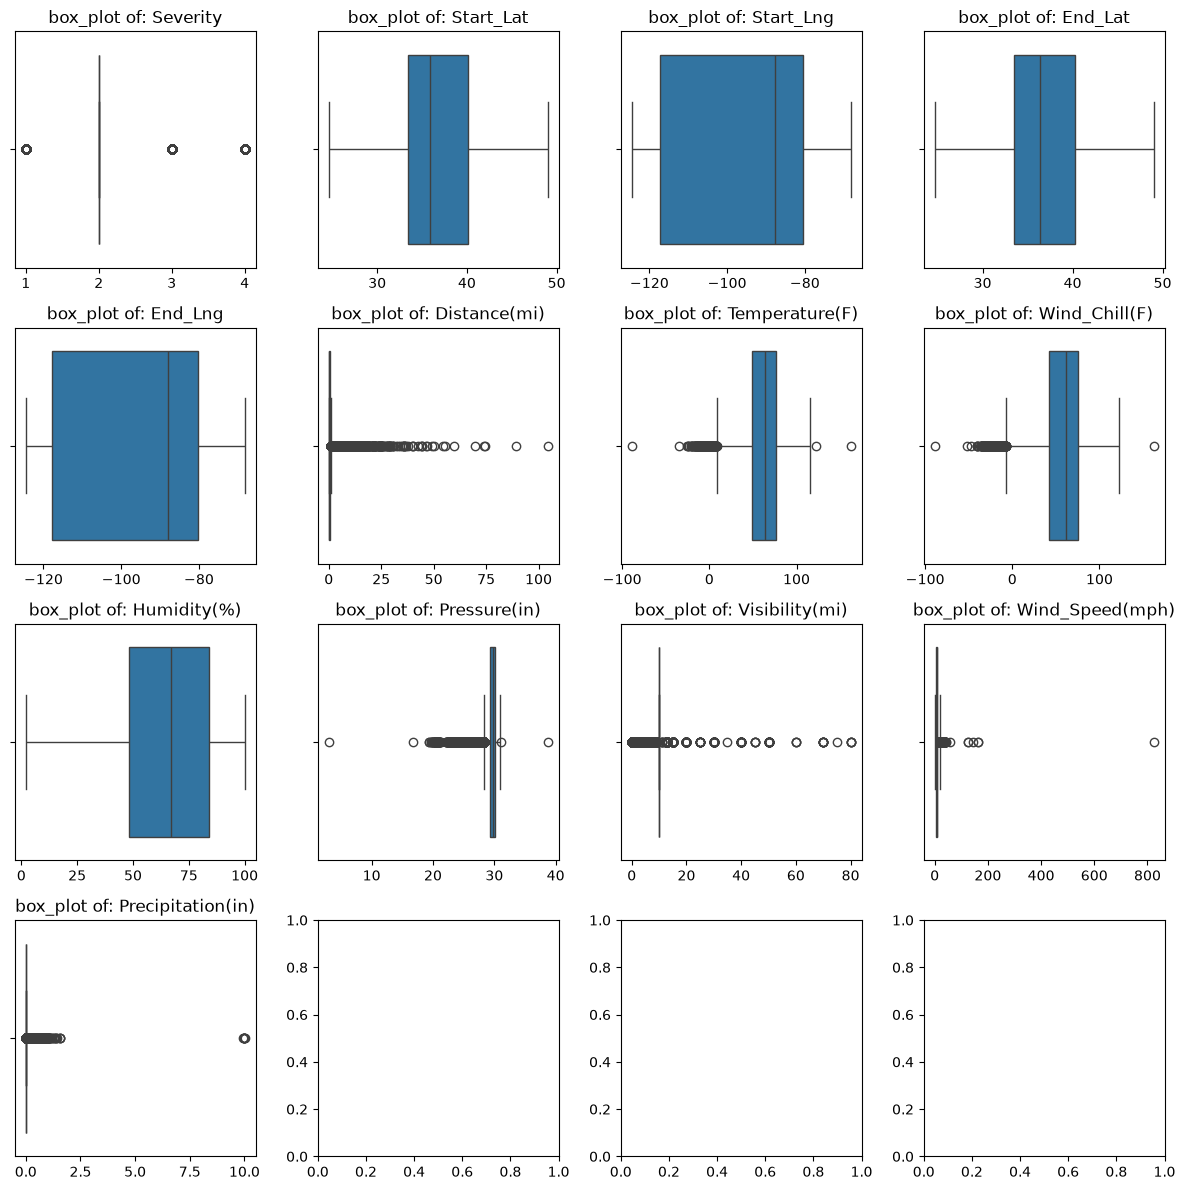

In [ ]:
sample_size = 100000
sample = df.sample(n = sample_size, random_state = 42)

num_cols_sample1 = sample.select_dtypes(include=[np.number]).columns.tolist()
total_plots = len(num_cols_sample1)
col_wrap = 4

num_rows = math.ceil(total_plots/col_wrap)

fig, axes = plt.subplots(
    nrows=num_rows, ncols=col_wrap, figsize=(12, num_rows * 3), sharex=False
)
axes = axes.flatten()
for i, col_name in enumerate(num_cols_sample1):
    sns.boxplot(data=sample, x=col_name, ax=axes[i])
    axes[i].set_title(f'box_plot of: {col_name}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**How to read a boxplot**
- A box sitting hard against one whisker means skew.
- A box collapsed to a line means one value dominates.

**Findings**
- **Severity** — dominated by class 2; the other classes are much rarer.
- **Wind_Speed(mph)** — a point at ~820, likely an error or unit mix-up.
- **Temperature(F)** — points at −90 and 160; +160°F is impossible.
- **Wind_Chill(F)** — derived from temperature; the same outliers appear.
- **Pressure(in)** — values down to 2–3. Sea level is ~29.9 and Denver ~24; below ~15 is impossible.
- **Precipitation(in)** — over 75% of values are 0, plus some outliers. Consider a binary feature (precipitation > 5 = 1, else 0).
- **Visibility(mi)** — most values sit at exactly 10; the outliers suggest 10 may be a placeholder — to check.

### Histograms

A histogram shows the shape of a column: where most values sit, how many rows land in each bin, how many peaks there are, and how far out the tails reach.

- Histograms of every numerical column on the same sample, 100 bins.
- x-axis labels removed — the title already names the column.

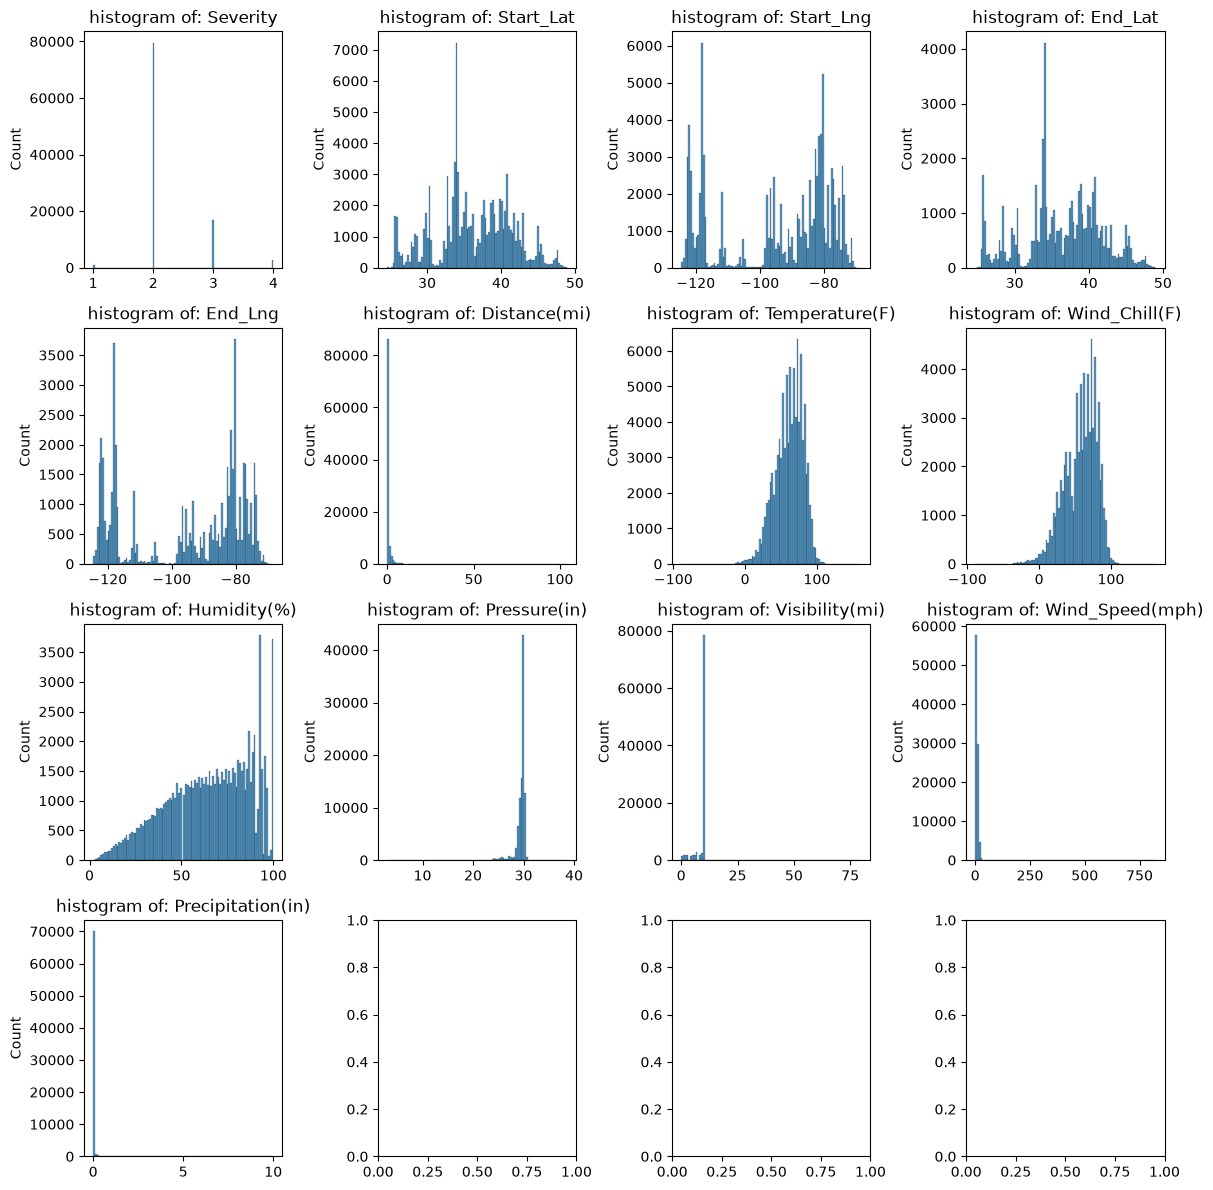

In [ ]:
fig, axes = plt.subplots(
    nrows=num_rows, ncols=col_wrap, figsize=(12, num_rows * 3), sharex=False
)
axes = axes.flatten()
for i, col_name in enumerate(num_cols_sample1):
    sns.histplot(data=sample, x=col_name, ax=axes[i], bins = 100)
    axes[i].set_title(f'histogram of: {col_name}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Findings** (100 bins)

- **Severity** — 4 discrete categories, dominated by 2. Ordinal, not continuous; bar chart is the correct plot.
- **Start_Lat / End_Lat** — multi-peaked, main cluster ~33–34. Reflects population density, not a data problem.
- **Start_Lng / End_Lng** — two clear peaks at ~−120 (West Coast) and ~−80 (East Coast); sparse interior. Data is heavily coastal/urban.
- **Distance(mi)** — extreme spike at 0, long right tail. This is length of road affected, not distance travelled. **Leakage: known only after the incident — exclude as a predictor.**
- **Temperature(F)** — peak ~65–70, tail to the left. Mildly **left-skewed**. Impossible values (−90, 160) seen in the boxplot are invisible here — too few rows to register.
- **Wind_Chill(F)** — same shape as temperature, derived from it. Inherits the same impossible values.
- **Humidity(%)** — mass at 90–100, thin tail down to 0. **Left-skewed** (tail on the left, not right).
- **Pressure(in)** — tight peak at ~29.9 with a left tail. Values below ~15 are physically impossible.
- **Visibility(mi)** — hard spike at 10. Not a placeholder: airport reports **cap** visibility at 10 miles, so the column is censored. Values above 10 need separate investigation.
- **Wind_Speed(mph)** — concentrated near 0 (calm). Check whether exact zeros are unusually frequent — may be "not recorded" in disguise.
- **Precipitation(in)** — >75% exactly 0 (no rain). Genuine zeros, separate from the 2.2m missing rows. Consider a binary "any precipitation" feature instead of the raw amount.

**Boxplot vs histogram:** boxplots flag individual extreme points; histograms show shape but bury anything rare. Run both

### Extreme percentiles and the mean vs median audit

In [ ]:
df.describe(include = 'number', percentiles = [0.5, 0.75,0.99, 0.9999])

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
99%,4.000000e+00,4.747886e+01,-7.148164e+01,4.727449e+01,-7.285381e+01,6.955000e+00,9.600000e+01,9.600000e+01,1.000000e+02,3.044000e+01,1.000000e+01,2.300000e+01,1.800000e-01
99.99%,4.000000e+00,4.887415e+01,-6.982946e+01,4.888346e+01,-6.962346e+01,4.918000e+01,1.110000e+02,1.110000e+02,1.000000e+02,3.082000e+01,7.000000e+01,4.300000e+01,2.545193e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


**Findings**
- Temperature, wind chill, pressure, visibility, wind speed and precipitation: a large jump between the 99.99th percentile and the max — outliers.
- Distance: both the 99.99th percentile and the max are extreme relative to the mean and median — the mean isn't safe to use.

- Define `audit_cols`: decide for each numerical column whether the mean is safe or the median should be used.
- For each column, calculate the median, 75th and 99.99th percentiles, plus mean, std and max.
- Check 1 — mean above the 75th percentile (already above the median) suggests outliers are pulling it.
- Check 2 — ratio of max to the 99.99th percentile: a large gap indicates an extreme tail.
- Check 3 — ratio of mean to median.
- Return a verdict and the reasons for each column.

In [ ]:
def audit_cols(df):
    result=[]
    num_cols = df.select_dtypes(include = [np.number]).columns
    for col in num_cols:
        median, p75, p99_99 = df[col].quantile([0.5, 0.75, 0.9999])
        mean, std, max = df[col].agg(['mean', 'std', 'max'])

        mean_greater_than_75 = mean > p75
        if p99_99>0:
            ratio = max / p99_99
        else:
            ratio = max if max > 0 else 1
        if median > 0:
            median_ratio = mean / median
        else:
            median_ratio = mean if mean > 0 else 1

        if mean_greater_than_75 or ratio > 1.2 and ratio > 3:
            verdict = 'median must be used , mean is likely biased'
            reason = []
            if mean_greater_than_75: reason.append('mean is greater than 75%')
            if median_ratio > 1.2: reason.append(f"Mean is {median_ratio:.1f}x higher than Median")
            if ratio > 3: reason.append(f'max is {ratio:.1f}x higher than 99.99% percentile (Extreme Tail)')
            reason_str = ", ".join(reason)
        else:
            verdict = "Use MEAN (Safe)"
            reason_str = "Data is balanced and symmetric"
        result.append({'column': col, 'mean': mean, 'median': median, 'std': std, 'max': max, 'p75': p75, 'p99_99': p99_99, 'mean_greater_than_75': mean_greater_than_75, 'ratio_max_to_p99_99': ratio, 'median_ratio': median_ratio, 'verdict': verdict, 'reason': reason_str})
    return pd.DataFrame(result)

In [ ]:
audit_report = audit_cols(df)
print(audit_report.to_string(index = False))

           column       mean     median       std         max        p75     p99_99  mean_greater_than_75  ratio_max_to_p99_99  median_ratio                                     verdict                                                                                                               reason
         Severity   2.212384   2.000000  0.487531    4.000000   2.000000   4.000000                  True             1.000000      1.106192 median must be used , mean is likely biased                                                                                             mean is greater than 75%
        Start_Lat  36.201195  35.823974  5.076079   49.002201  40.084959  48.874151                 False             1.002620      1.010530                             Use MEAN (Safe)                                                                                       Data is balanced and symmetric
        Start_Lng -94.702545 -87.766616 17.391756  -67.113167 -80.353676 -69.829456           

- Split the audit report into columns where the mean is safe and columns where the median should be used.
- Next: inspect the median columns further for anomalies.

In [ ]:
mean_cols = audit_report[audit_report.iloc[:, -1] == "Data is balanced and symmetric"]
median_cols = audit_report[audit_report.iloc[:, -1] != "Data is balanced and symmetric"]

### Skew and kurtosis

These show *why* the mean is unsafe for particular columns. Values rounded to 2 decimal places.
- **Skew** — how asymmetric the column is.
- **Kurtosis** — how heavy the tails are: how often extreme values occur and how far out they sit.
  - 0 — normal
  - above 0 — heavy tails
  - below 0 — flat, light tails

In [ ]:
round(df.select_dtypes(include = 'number').skew(), 2)
round(df.select_dtypes(include = 'number').kurtosis(), 2)

Severity                 3.30
Start_Lat               -0.53
Start_Lng               -1.36
End_Lat                 -0.56
End_Lng                 -1.56
Distance(mi)          1649.60
Temperature(F)          -0.00
Wind_Chill(F)            0.15
Humidity(%)             -0.72
Pressure(in)            21.84
Visibility(mi)          81.89
Wind_Speed(mph)       1085.48
Precipitation(in)    10710.92
dtype: float64

## 3. Categorical features

- Build the list of categorical columns.
- Count missing values in each categorical column.

In [ ]:
cat_cols = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols].isna().sum()

ID                            0
Source                        0
Start_Time                    0
End_Time                      0
Description                   5
Street                    10869
City                        253
County                        0
State                         0
Zipcode                    1915
Country                       0
Timezone                   7808
Airport_Code              22635
Weather_Timestamp        120228
Wind_Direction           175206
Weather_Condition        173459
Amenity                       0
Bump                          0
Crossing                      0
Give_Way                      0
Junction                      0
No_Exit                       0
Railway                       0
Roundabout                    0
Station                       0
Stop                          0
Traffic_Calming               0
Traffic_Signal                0
Turning_Loop                  0
Sunrise_Sunset            23246
Civil_Twilight            23246
Nautical

- Count unique values in each categorical column.
- Convert all column names to lower case for consistency.

In [ ]:
df.loc[:, cat_cols].nunique()
df.columns = df.columns.str.lower()

### `source`

- `source`: unique values and their proportions, including NaN.
- **Finding:** 3 categories — convert to `category` dtype to save memory.

In [ ]:
df.source.unique()
df.source.value_counts(normalize = True, dropna = False)
df.source = df.source.astype('category')

### `country`

- `country`: check its values.
- **Finding:** every row is USA — no information. Drop the column.

In [ ]:
df.country.value_counts(normalize = True, dropna = False)
df.drop(columns = ['country'], inplace = True)

- Rebuild the categorical column list after dropping `country`, and recount unique values.

In [ ]:
cat_cols_1 = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols_1].nunique() 

id                       7728394
source                         3
start_time               6131796
end_time                 6705355
description              3761578
street                    336306
city                       13678
county                      1871
state                         49
zipcode                   825094
timezone                       4
airport_code                2045
weather_timestamp         941331
wind_direction                24
weather_condition            144
amenity                        2
bump                           2
crossing                       2
give_way                       2
junction                       2
no_exit                        2
railway                        2
roundabout                     2
station                        2
stop                           2
traffic_calming                2
traffic_signal                 2
turning_loop                   1
sunrise_sunset                 2
civil_twilight                 2
nautical_t

### `wind_direction`

- `wind_direction`: proportions and counts.
- **Finding:** duplicates caused by inconsistent naming (e.g. North vs N, CALM vs calm).
- Valid directions: N, E, S, W, NE, NW, SE, SW, NNE, ENE, ESE, SSE, SSW, WSW, WNW, NNW.
- Replace full words with abbreviations, fill NaN with 'NA', convert to `category`.
- Convert all values to upper case for consistency.

In [ ]:
df.wind_direction.value_counts(normalize = True, dropna = False)
df.wind_direction.value_counts()

df.wind_direction = df.wind_direction.replace({'North': 'N',
                                               'East': 'E',
                                               'South': 'S',
                                               'West': 'W',
                                               'CALM': 'calm',
                                               'Variable': 'var',
                                               'Var': 'var',
                                               'var': 'var'}, regex = True).fillna('NA').astype('category')

df.wind_direction = df.wind_direction.str.upper()

- Check `wind_direction` proportions after cleaning.
- **Finding:** 2.26% of values are NA — note for later.

In [ ]:
df.wind_direction.value_counts(normalize = True, dropna = False)*100

wind_direction
CALM    17.211610
S        7.729471
W        7.099327
N        5.959013
SSW      4.979560
E        4.948751
WNW      4.901161
NW       4.779156
VAR      4.717177
SW       4.715986
WSW      4.578002
SSE      4.517239
NNW      4.314312
SE       3.815812
ESE      3.471756
NE       3.346607
ENE      3.344472
NNE      3.303545
NA       2.267043
Name: proportion, dtype: float64

### `timezone`

- `timezone`: proportions of each value.
- **Finding:** 7 values in 'US/...' format.
- Map to short lower-case names, fill NaN with 'NA', convert to `category`.

In [ ]:
df.timezone.value_counts(normalize = True, dropna = False)
df.timezone = df.timezone.replace({'US/Eastern': 'eastern',
                                   'US/Central': 'central',
                                   'US/Mountain': 'mountain',
                                   'US/Pacific': 'pacific',
                                   'UTC': 'utc'}, regex = True).fillna('NA').astype('category')

In [ ]:
df.timezone.value_counts(normalize = True, dropna = False) 
df.rename(columns = {'timezone': 'timezone(us)'}, inplace = True)

- Rebuild the categorical column list after the renames.

In [ ]:
cat_cols2 = df.select_dtypes(exclude = [np.number]).columns.tolist()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 45 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   id                     str     
 1   source                 category
 2   severity               int64   
 3   start_time             str     
 4   end_time               str     
 5   start_lat              float64 
 6   start_lng              float64 
 7   end_lat                float64 
 8   end_lng                float64 
 9   distance(mi)           float64 
 10  description            str     
 11  street                 str     
 12  city                   str     
 13  county                 str     
 14  state                  str     
 15  zipcode                str     
 16  timezone(us)           category
 17  airport_code           str     
 18  weather_timestamp      str     
 19  temperature(f)         float64 
 20  wind_chill(f)          float64 
 21  humidity(%)            float64 
 22  press

### Road features and light conditions

- Count unique values in the road-feature and light-condition columns (28–46).
- Goal: see whether any can be combined.
- **Finding:** road features are boolean (True/False); light columns are Day/Night.
- Not run: `df.loc[:, cat_cols2].nunique()`, `df.iloc[:, 28:46]`.

In [ ]:
df.iloc[:, 28:46].nunique()

amenity                  2
bump                     2
crossing                 2
give_way                 2
junction                 2
no_exit                  2
railway                  2
roundabout               2
station                  2
stop                     2
traffic_calming          2
traffic_signal           2
turning_loop             1
sunrise_sunset           2
civil_twilight           2
nautical_twilight        2
astronomical_twilight    2
dtype: int64

#### `turning_loop`

- `turning_loop`: check its values.
- **Finding:** 100% False, no missing and no True values. Drop the column.

In [ ]:
df.loc[:, ['turning_loop']].value_counts(normalize = True, dropna = False)*100
df.drop(columns = 'turning_loop', inplace = True)

#### Boolean dtypes

Re-read the dtypes and confirm the road features are boolean.

In [ ]:
cat_cols3 = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols3].dtypes

id                            str
source                   category
start_time                    str
end_time                      str
description                   str
street                        str
city                          str
county                        str
state                         str
zipcode                       str
timezone(us)             category
airport_code                  str
weather_timestamp             str
wind_direction             object
weather_condition             str
amenity                      bool
bump                         bool
crossing                     bool
give_way                     bool
junction                     bool
no_exit                      bool
railway                      bool
roundabout                   bool
station                      bool
stop                         bool
traffic_calming              bool
traffic_signal               bool
sunrise_sunset                str
civil_twilight                str
nautical_twili

- Select the boolean columns.
- Calculate the True/False percentage for each.

In [ ]:
bool_col = df.select_dtypes(include = ['bool'])

proportion = bool_col.apply(lambda x: x.value_counts(normalize = True)*100)

- Transpose the table for easier reading.
- **Finding:** mostly False — six features are True in under 1% of rows, so estimates for them will be fragile.

In [ ]:
proportion.transpose()

,False,True
amenity,98.753506,1.246494
bump,99.954531,0.045469
crossing,88.694119,11.305881
give_way,99.526655,0.473345
junction,92.607235,7.392765
no_exit,99.747101,0.252899
railway,99.133339,0.866661
roundabout,99.996778,0.003222
station,97.387543,2.612457
stop,97.226190,2.773810


#### Do the light columns agree?

- Crosstab `sunrise_sunset` against `astronomical_twilight` to see how often they agree.
- Diagonal: both columns say the same thing (both Day or both Night).
- Off-diagonal: they disagree. If they often disagree, each adds information; if they rarely do, they're highly correlated and one is redundant.

In [ ]:
pd.crosstab(df.sunrise_sunset, df.astronomical_twilight, normalize = True).round(2)

astronomical_twilight,Day,Night
sunrise_sunset,,
Day,0.69,0.00
Night,0.14,0.17


- Same agreement check for `civil_twilight` against `nautical_twilight`.

In [ ]:
pd.crosstab(df.civil_twilight, df.nautical_twilight, normalize = True).round(2)

nautical_twilight,Day,Night
civil_twilight,,
Day,0.74,0.00
Night,0.05,0.21


**Interpretation**

The four light columns rank by when each considers day to end and night to start: `sunrise_sunset` → `civil_twilight` → `nautical_twilight` → `astronomical_twilight`.

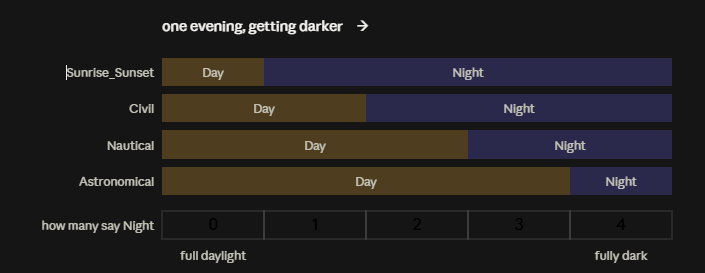

Reading down the bottom row (5 segments): 0 = all four say Day, 1 = one says Night, 2 = two say Night, and so on up to 4.

**Next:** build a column scoring each row from 0 to 4.

## Checkpoint

Save as `df_temp` so the notebook doesn't need a full re-run if the kernel struggles.

In [ ]:
df.to_parquet('../data/df_temp.parquet', engine='fastparquet', index=True)

- Reload imports and the checkpoint from parquet.

In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
df_temp = pq.read_table('../data/df_temp.parquet').to_pandas()


## 4. Weather condition

The last categorical column to profile.

- `weather_condition`: convert to string, lower case, and strip whitespace.
- **Finding:** rows missing weather tend to be missing many other columns too.
- **Finding:** stripping whitespace reduced unique values from 145 to 144.

In [ ]:
df_temp.weather_condition = df_temp.weather_condition.astype('str')
df_temp.weather_condition = df_temp.weather_condition.str.lower()
df_temp[df_temp.weather_condition.isna()]
df_temp.weather_condition = df_temp.weather_condition.str.strip()

In [ ]:
df_temp.weather_condition.nunique()

144

In [ ]:
df_temp.weather_condition.value_counts(normalize= True, dropna = False, ascending = False).cumsum()

weather_condition
fair                         0.331350
mostly cloudy                0.462838
cloudy                       0.568563
clear                        0.673209
partly cloudy                0.763651
                               ...   
heavy sleet / windy          0.999999
sand / windy                 1.000000
heavy rain shower / windy    1.000000
blowing snow nearby          1.000000
drifting snow                1.000000
Name: proportion, Length: 145, dtype: float64

**Findings**
- The top 13 values cover 95% of rows (cumulative proportion) — the rest are mostly variations of them.

**Note for cleaning:** list all values and find the shared underlying conditions; check whether they map onto the top 13.

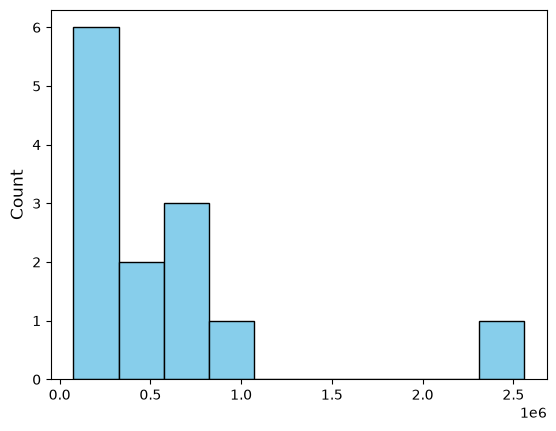

In [ ]:
# plot top 13 = 95% of total proportion of results
top_13_conditions = df_temp['weather_condition'].value_counts(dropna=False, ascending=False)[:13]
top_13_conditions.plot(kind='hist', color='skyblue', edgecolor='black')
plt.ylabel('Count', fontsize=12)
plt.show()

## 5. Light score

- Define the four light columns and view them.
- **Finding:** 23,246 rows are NaN — to be handled later.

In [ ]:
light_list = ['sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight']
df_temp.loc[:, light_list]

,sunrise_sunset,civil_twilight,nautical_twilight,astronomical_twilight
index,,,,
0,Night,Night,Night,Night
1,Night,Night,Night,Day
2,Night,Night,Day,Day
3,Night,Day,Day,Day
4,Day,Day,Day,Day
...,...,...,...,...
7728389,Day,Day,Day,Day
7728390,Day,Day,Day,Day
7728391,Day,Day,Day,Day


- Encode Day = 0, Night = 1.

In [ ]:
df_temp[light_list] = df_temp[light_list].replace({'Day' :0, 'Night': 1}, regex = False)

- Proportion of Day/Night in each light column.
- Sum the four columns into `light_score` (0–4). `skipna=False` keeps the row NaN if any column is missing.
- **Finding:** `light_score` contains 0, 1, 2, 3, 4 and NaN.

In [ ]:
df_temp[light_list].apply(lambda x: x.value_counts(normalize = True))
df_temp['light_score'] = df_temp[light_list].sum(axis= 1, skipna = False)
df_temp['light_score'].unique()

array([4, 3, 2, 1, 0, nan], dtype=object)

- Proportion of each `light_score` value.
- Crosstab `light_score` against `sunrise_sunset` — any score of 0 should be Day, since `sunrise_sunset` is the least strict column.

In [ ]:
df_temp.light_score.value_counts(normalize= True, dropna= False)

pd.crosstab(df_temp.light_score, df_temp.sunrise_sunset, normalize = True).round(2)

sunrise_sunset,0,1
light_score,,
0,0.69,0.00
1,0.00,0.05
2,0.00,0.05
3,0.00,0.04
4,0.00,0.17


**Interpretation**
- Astronomical twilight is the strictest — the last of the four to switch to Night, so it only says Night when all four do (`light_score` = 4).
- Share of night accidents: 1 − 0.69 = 0.31. Of that 0.31, 0.14 is not astronomical night (true dark).
- So 0.14 / 0.31 ≈ 0.44 — about 44% of night accidents happen during twilight.

### Missing light values

- Check whether the missing light values fall on the same rows, and what else is missing on those rows.
- **Finding:** those rows are also missing precipitation, wind chill, city, end lat/lng, and some wind speed.

In [ ]:
light_data_missing = df_temp[df_temp.loc[:, light_list].isna().any(axis=1)]
light_data_missing.isna().sum()

id                           0
source                       0
severity                     0
start_time                   0
end_time                     0
start_lat                    0
start_lng                    0
end_lat                   1675
end_lng                   1675
distance(mi)                 0
description                  0
street                     177
city                       253
county                       0
state                        0
zipcode                     41
timezone(us)                 0
airport_code              2575
weather_timestamp         2744
temperature(f)            2898
wind_chill(f)             3172
humidity(%)               2948
pressure(in)              2862
visibility(mi)            2942
wind_direction               0
wind_speed(mph)           3010
precipitation(in)         2963
weather_condition         2924
amenity                      0
bump                         0
crossing                     0
give_way                     0
junction

## 6. Time columns

`start_time`, `end_time` and `weather_timestamp` aren't categorical — they should be datetimes.

In [ ]:
df_temp.start_time

index
0          2016-02-08 05:46:00
1          2016-02-08 06:07:59
2          2016-02-08 06:49:27
3          2016-02-08 07:23:34
4          2016-02-08 07:39:07
                  ...         
7728389    2019-08-23 18:03:25
7728390    2019-08-23 19:11:30
7728391    2019-08-23 19:00:21
7728392    2019-08-23 19:00:21
7728393    2019-08-23 18:52:06
Name: start_time, Length: 7728394, dtype: str

- `start_time`, `end_time` and `weather_timestamp` are stored as strings.
- Convert to datetime. Still to do: align across time zones.

In [ ]:
df_temp.start_time.dtype
df_temp.end_time.dtype
df_temp['start_time'] = pd.to_datetime(df_temp['start_time'], format="ISO8601")
df_temp['end_time'] = pd.to_datetime(df_temp['end_time'], format="ISO8601")
df_temp['weather_timestamp'] = pd.to_datetime(df_temp['weather_timestamp'], format="ISO8601")

### Duration

- Calculate accident duration (`time_delta`) as end minus start, in seconds.
- Summary statistics, skew and kurtosis of the duration.
- **Finding:** very high kurtosis — extreme values sit far out in the tail.
- Convert to minutes

In [ ]:
df_temp['time_delta'] = df_temp.end_time - df_temp.start_time
df_temp['time_delta'] = df_temp['time_delta'].dt.total_seconds()
df_temp['time_delta'] = df_temp['time_delta'] / 60
df_temp['time_delta'].describe(percentiles = [0.5, 0.75, 0.99, 0.9999])
df_temp['time_delta'].skew()
df_temp['time_delta'].kurtosis()

np.float64(3659.599743127051)

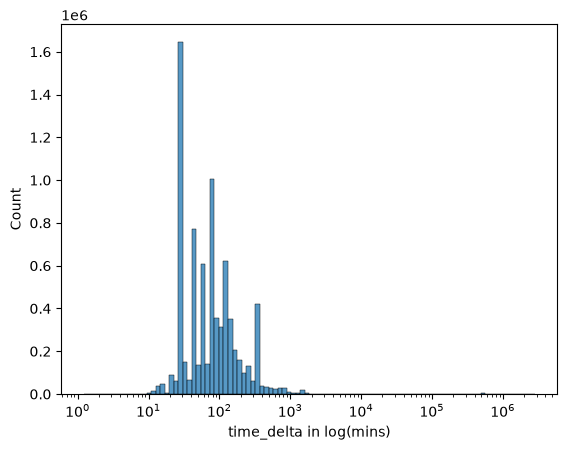

In [ ]:
sns.histplot(x=df_temp.time_delta, bins=100, log_scale=True)
plt.xlabel('time_delta in log(mins)')
plt.show()

In [ ]:
df_temp.columns

Index(['id', 'source', 'severity', 'start_time', 'end_time', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'distance(mi)', 'description',
       'street', 'city', 'county', 'state', 'zipcode', 'timezone(us)',
       'airport_code', 'weather_timestamp', 'temperature(f)', 'wind_chill(f)',
       'humidity(%)', 'pressure(in)', 'visibility(mi)', 'wind_direction',
       'wind_speed(mph)', 'precipitation(in)', 'weather_condition', 'amenity',
       'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway',
       'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal',
       'sunrise_sunset', 'civil_twilight', 'nautical_twilight',
       'astronomical_twilight', 'light_score', 'time_delta'],
      dtype='str')

## 7. Geographical features

`street`, `city`, `county`, `state`, `zipcode`, `airport_code` — check cardinality.
- These are nested: each narrows down the location of the one before.
- For each column: is it coarse enough to learn from, and does it add anything the others don't?

- Geographical features: percentage of missing values per column.
- Not run: `df_temp.loc[:, geo_features].apply(lambda x: x.unique().sum())`.

In [ ]:
geo_features = ['street', 'city', 'county', 'state', 'zipcode', 'airport_code']
df_temp.loc[:, geo_features].isna().mean()

street          0.001406
city            0.000033
county          0.000000
state           0.000000
zipcode         0.000248
airport_code    0.002929
dtype: float64

### `state`

- Plot accident counts by state.
- **Finding:** Florida has the highest count. Keep `state` — it supports state-level responses.
- Not run: `df_temp.state.unique()`.

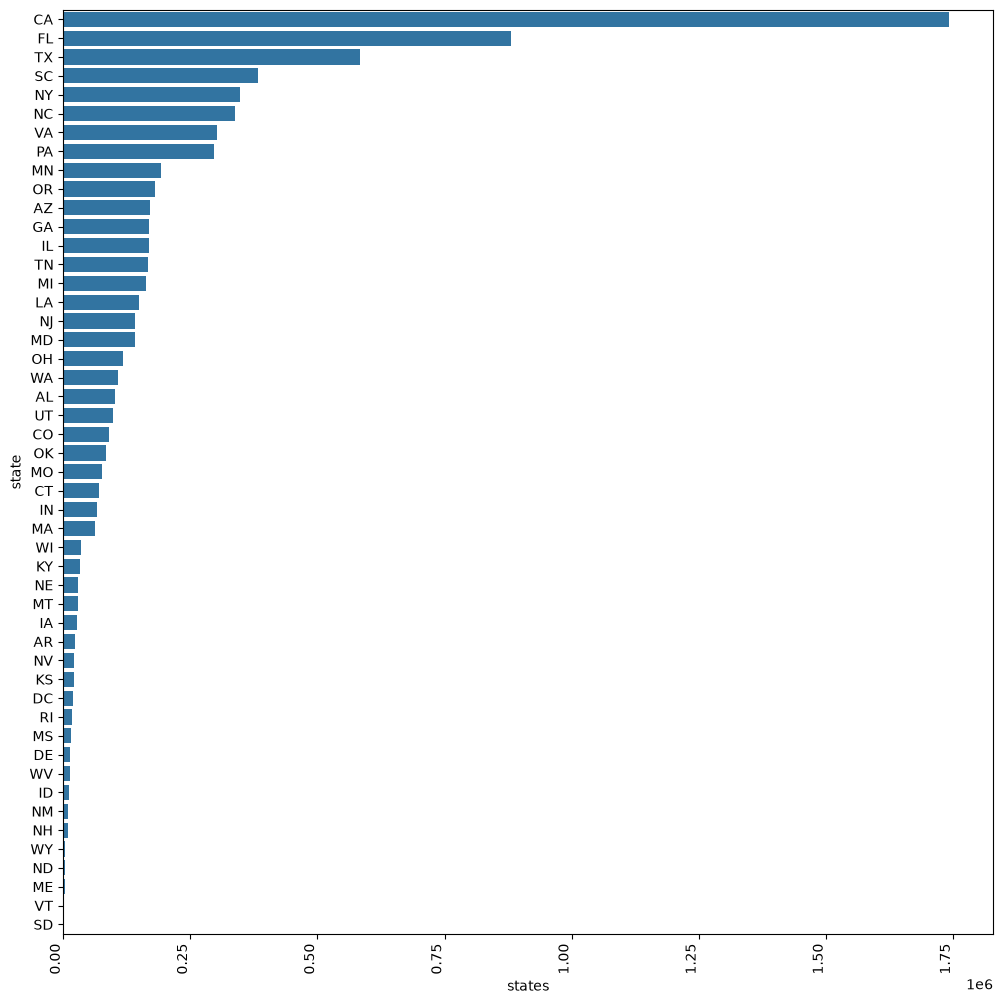

In [ ]:
plt.figure(figsize=(12,12))
sns.countplot(data = df_temp, y = 'state', order = df_temp.state.value_counts(ascending = False).index)
plt.xticks(rotation = 90, ha = 'right')
plt.xlabel('states')
plt.show()

### `city` and `county`

- Check whether city and county names repeat across states (`set` lists the distinct states per name).
- **Finding:** many names appear in several states, so they're ambiguous on their own and add no information beyond `state` and lat/lng.

In [ ]:
df_temp.groupby('county')['state'].apply(set)
df_temp.groupby('city')['state'].apply(set)

city
Aaronsburg                  {PA}
Abbeville       {LA, MS, AL, SC}
Abbotsford                  {WI}
Abbott                      {TX}
Abbottstown                 {PA}
                      ...       
Zortman                     {MT}
Zumbro Falls                {MN}
Zumbrota                    {MN}
Zuni                        {VA}
Zwingle                     {IA}
Name: state, Length: 13678, dtype: object

**Decision:** drop `city` and `county` — `state` and lat/lng already cover location at the coarse and precise levels.

In [ ]:
df_temp.drop(columns=['county','city'], inplace = True)

### `zipcode` and `street`

- Count unique zipcodes and streets.
- To do: look at 20 random zipcodes to spot the formats; look at 30 street names to spot road-type patterns.
- To do: cross-check `airport_code` against weather missingness — weather readings are copied from the nearest airport station.

In [ ]:
df_temp.zipcode.nunique()
df_temp.street.nunique()

336306

In [ ]:
df_temp.drop(columns=['zipcode'], inplace = True)

### Road type from `street`

- Define `street_type_shift`: extract the road type from the street name.
- Regex scans for road-type prefixes and suffixes anywhere in the text.
- A dictionary standardises the abbreviations; unmatched rows become 'Local/Other'.
- `.str.title()` makes the matches line up with the dictionary keys (e.g. 'st' → 'St').

In [ ]:
def street_type_shift(df, column_name='street'):
    s = df[column_name].str.lower()

    conditions = [
        s.isna(),
        s.str.contains(r'\bi-|\binterstate\b', na=False),
        s.str.contains(r'\bus\b', na=False),
        s.str.contains(r'\b(?:fwy|freeway|expy|expressway|pkwy|parkway|tpke|turnpike|tollway)\b', na=False),
        s.str.contains(r'\b(?:hwy|highway|route|rte|sr)\b|\b[a-z]{2}-\d', na=False),
        s.str.contains(r'\b(?:st|street|ave|avenue|rd|road|blvd|boulevard|ln|lane|dr|drive|way|ct|court|pl|place|cir|circle|ter|trl)\b', na=False),
    ]
    labels = ['Unknown', 'Interstate', 'US Highway', 'Freeway', 'State Highway', 'Local']

    return pd.Series(np.select(conditions, labels, default='Other'), index=df.index)

In [ ]:
f_temp = df_temp.drop(columns=['street_Type'], errors='ignore')
df_temp['street_type'] = street_type_shift(df_temp)
df_temp['street_type'].value_counts(normalize=True)

street_type
Local            0.443609
Interstate       0.250567
State Highway    0.133458
Freeway          0.098885
US Highway       0.037611
Other            0.034463
Unknown          0.001406
Name: proportion, dtype: float64

## 8. Severity (target)

View the distribution of the target.

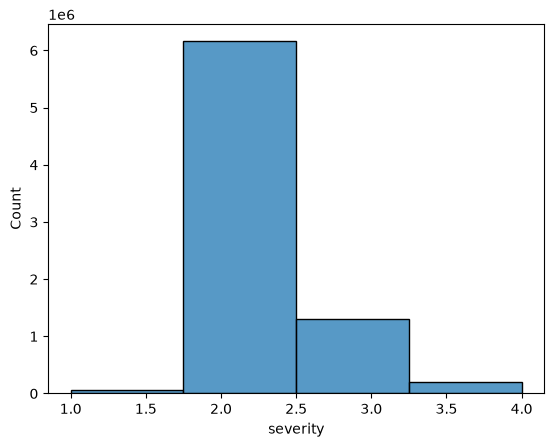

In [ ]:
df_temp.severity.astype('category')
sns.histplot(x = df_temp.severity, bins= 4)
plt.show()

In [ ]:
df_temp.severity.value_counts(normalize = True, dropna = False)*100

severity
2    79.667017
3    16.812510
4     2.648804
1     0.871669
Name: proportion, dtype: float64

In [ ]:
df_temp.wind_direction = df_temp.wind_direction.replace({
                                               'VARIABLE': 'VAR'}, regex = True).fillna('NA').astype('category')
#final cleaning

### Plotting the remaining categorical featres

    - source	Bar of proportions — only 3 bars
    - timezone(us)	Bar of proportions — 4–5 bars
    - wind_direction	Bar of proportions, sorted by frequency
    - Boolean road features	One horizontal bar chart of the True % for each feature — plot your existing proportion table
    - light_score	Bar of counts, kept in order 0 → 4, not sorted by frequency
    - street_type	Bar of counts, once the function is fixed

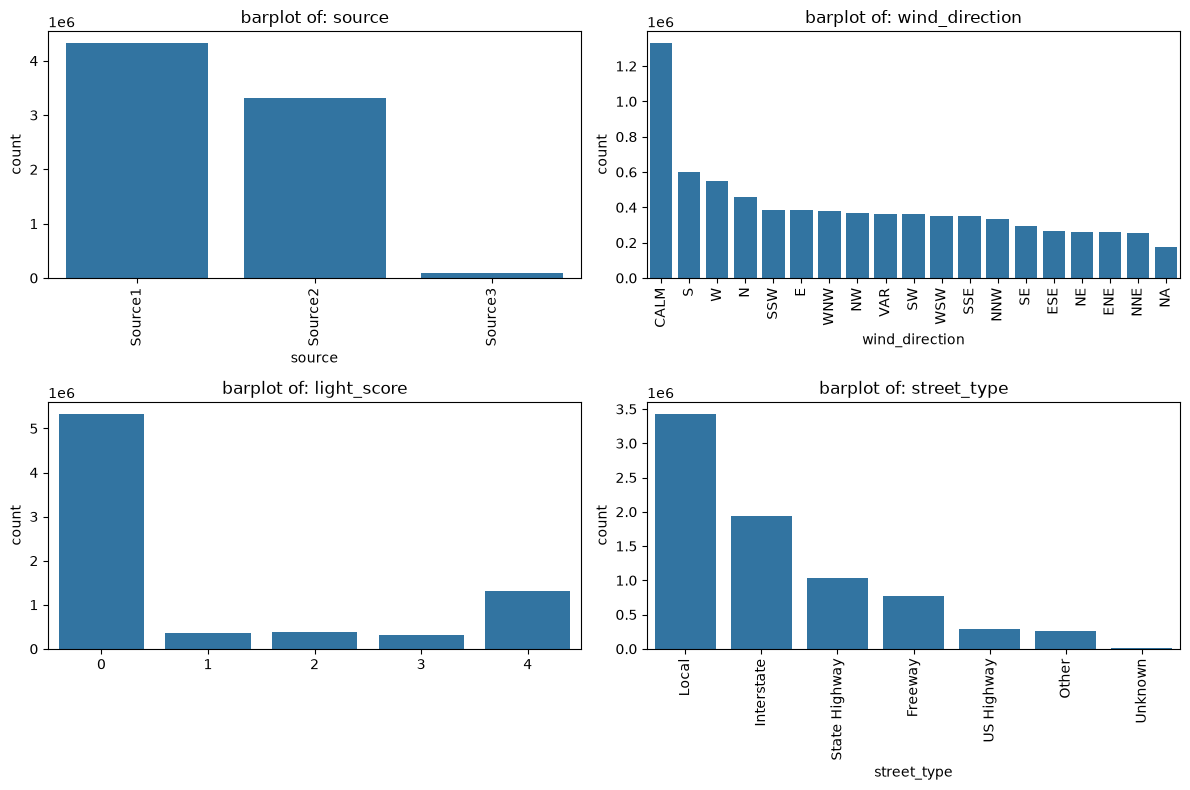

In [ ]:
cols = ['source', 'wind_direction', 'light_score', 'street_type']

fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(12,8), sharex=False
)
axes = axes.flatten()
for i, col_name in enumerate(cols):
    if col_name == 'light_score':
        sns.countplot(data=df_temp, x=col_name, order=df_temp[col_name].value_counts(ascending = False).sort_index().index, ax=axes[i])
        axes[i].set_title(f'barplot of: {col_name}')
        axes[i].set_xlabel('')
    else:
        sns.countplot(data=df_temp, x=col_name, order=df_temp[col_name].value_counts().index, ax=axes[i])
        axes[i].set_title(f'barplot of: {col_name}')
        axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# drop the descriptoins column it holds no value and will not contribute to the model, helpful to have for descriptive infomration though:
descriptions = df_temp.description
df_temp.drop(columns = 'description', inplace = True)

In [ ]:
#duplicates
exclude_cols = ['id']

# 3. Create the subset of columns to check for duplicates
check_cols = [col for col in df_temp.columns if col not in exclude_cols]

# 4. Find the duplicate rows (returns True for the duplicate records)
# Use keep=False to flag ALL occurrences, or keep='first' to flag subsequent ones
duplicates = df_temp[df_temp.duplicated(subset=check_cols, keep='first')]

len(duplicates)


140811

-  `wind_direction`: CALM lines up with `wind_speed` =0


In [ ]:
pd.crosstab(df_temp['wind_speed(mph)'], df_temp['wind_direction'])
is_aligned = df_temp.loc[df_temp['wind_direction'] == 'CALM', 'wind_speed(mph)'].eq(0).all()
print(f"Does CALM always line up with 0 mph? {is_aligned}")



Does CALM always line up with 0 mph? False


- Temperature / wind chill: impossible values in the same rows? −90 and 160°F
-  Missing weather overlaps missing `airport_code`?

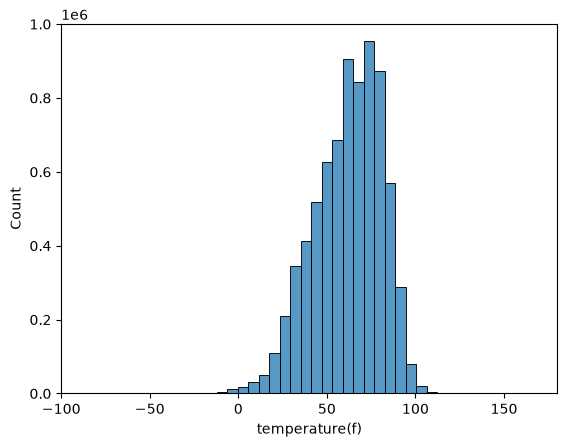

In [ ]:
sns.histplot(df_temp['temperature(f)'],bins= 50)
plt.xlim(-100, 180)
plt.show()

In [ ]:
#-  Missing weather overlaps missing `airport_code`?
df_temp.loc[:, ['airport_code', 'weather_condition', 'weather_timestamp']].isna().sum() 

airport_code          22635
weather_condition    173459
weather_timestamp    120228
dtype: int64

## Checkpoint

- Checkpoint: save `df_temp` to parquet.

In [ ]:
df_temp.to_parquet('../data/df_temp.parquet', engine='fastparquet', index=True)

## Step 2 - Bivariate and Multivariate analysis 

- Take one column at a time and ask: does this change the chance of a severe accident?
1. would i know this at the moment of the accident? 
    no --> it is leakage. Do not treat it as a feature (duration, distance, description, end lng/lat)
    yes --> not an illegal feature, you can keep it in 
2. what type is it - this decides the method 
    - numerical - compare its median for severe vs non-severe (is it significantly different, hypothesis test, t test?) * box plot
    - categorical - % severity for each category (bar plot)
    - boolean - % severe when its true vs % severe when its false 
3. does % severity change and by how much?
    overal rate is ~20% = a big gap from that is worth noticing, a tiny gap shows little effect

4. could something else explain this?
    - weather, time of day, source, road type, state, 
    - yes - split that column - check again - this is a multivariate step

### Order to work through
1. Can I trust the target? — source, year, duration
2. Weather
3. Time and light — hour, weekday, month, light_score
4. Road — street_type, the True/False road features
5. Place — state

In [118]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from IPython.display import display

df_temp_2 = pq.read_table('../data/df_temp.parquet').to_pandas()


- Seperate data column into seperate columns for downstream analysis 

In [119]:
df_temp_2['severity'].value_counts(normalize = True, dropna = False)
df_temp_2.start_time = pd.to_datetime(df_temp_2.start_time)
df_temp_2['start_year'] = df_temp_2.start_time.dt.year
df_temp_2['start_year'] = df_temp_2.start_time.dt.year
df_temp_2['start_hour'] = df_temp_2.start_time.dt.hour
df_temp_2['start_day'] = df_temp_2.start_time.dt.weekday # 0-6 mon - sun
df_temp_2['start_month'] = df_temp_2.start_time.dt.month


In [120]:
def street_type_shift(df, column_name="street"):
    s = df[column_name].astype(str).str.lower().str.strip()

    conditions = [
        s.isna() | s.isin(["nan", "none", ""]),
        s.str.contains(
            r"\bi[-\s]?\d+|\binterstate\b|\bi\s+\d+", na=False, regex=True
        ),
        s.str.contains(
            r"\b(?:us|u\.s\.)\b|\bus[-\s]?\d+|\b us \d+", na=False, regex=True
        ),
        s.str.contains(
            r"\b(?:sr|state hwy|state route|rt|rte|route)\b|\b[a-z]{2}[-\s]?\d+",
            na=False,
            regex=True,
        ),
        s.str.contains(
            r"\b(?:fwy|freeway|expy|expressway|pkwy|parkway|tpke|turnpike|tollway|skyway|bypass)\b",
            na=False,
            regex=True,
        ),
        s.str.contains(
            r"\b(?:cr|co rd|county rd|county road|fm|farm|market|parish|township)\b",
            na=False,
            regex=True,
        ),
        s.str.contains(
            r"\b(?:st|street|ave|avenue|rd|road|blvd|boulevard|ln|lane|dr|drive|way|ct|court|pl|place|cir|circle|ter|terrace|trl|trail|path|run|plz|plaza|aly|alley|pass|loop|ramp|pkwy|ext|extension|pt|point)\b",
            na=False,
            regex=True,
        ),
    ]
    labels = [
        "Unknown",
        "Interstate",
        "US Highway",
        "State Highway",
        "Freeway",
        "County Road",
        "Local",
    ]

    return pd.Series(np.select(conditions, labels, default="Other"), index=df.index)

df_temp_2["street_type"] = street_type_shift(df_temp_2)

Source 2 overall severity cases 

In [121]:
source2 = df_temp_2[df_temp_2["source"].str.contains("source2", case=False, na=False)]
source2.severity.isin([3,4]).mean()*100


np.float64(33.924613046697)

- Severe accidents ~ 34% of the dataset - this is our baseline
- Pick one accident at random from the whole dataset. There's a 34% chance it's severe (3 or 4). That's your best guess when you know nothing else about it.

## 2.2 Weather — first pass, and the synonym anomaly

In [122]:
display(
    df_temp_2.weather_condition.value_counts(normalize= True, dropna = False),
    source2.weather_condition.value_counts(normalize= True, dropna = False)
)

weather_condition
fair                         3.313498e-01
mostly cloudy                1.314885e-01
cloudy                       1.057247e-01
clear                        1.046457e-01
partly cloudy                9.044208e-02
                                 ...     
heavy sleet / windy          1.293930e-07
sand / windy                 1.293930e-07
heavy rain shower / windy    1.293930e-07
blowing snow nearby          1.293930e-07
drifting snow                1.293930e-07
Name: proportion, Length: 145, dtype: float64

weather_condition
fair                      2.177294e-01
clear                     1.874149e-01
mostly cloudy             1.387256e-01
partly cloudy             9.531784e-02
overcast                  8.803061e-02
                              ...     
patches of fog / windy    3.025377e-07
partial fog / windy       3.025377e-07
heavy smoke               3.025377e-07
heavy freezing drizzle    3.025377e-07
light blowing snow        3.025377e-07
Name: proportion, Length: 131, dtype: float64

- Weather Analysis and Source confounders - Full dataset

In [123]:
weather_types = ['snow', 'rain', 'fair', 'overcast', 'cloud', 'clear', 'haze', 'fog']
resulting_weather_percentages = []

for i in weather_types:
    condition_mask = df_temp_2.weather_condition.str.contains(i, case=False, na=False)
    severity_mask = df_temp_2.severity.isin([3, 4])

    severe_acc = len(df_temp_2[condition_mask & severity_mask])
    condition = len(df_temp_2[condition_mask])
        
    if condition > 0:
        percentage_severe_weather = (severe_acc / condition) * 100
    else:
        percentage_severe_weather = 0.0
            
    resulting_weather_percentages.append(percentage_severe_weather)

print(resulting_weather_percentages)



[20.036442332806807, 23.34556440365675, 11.721092420371788, 34.95034816358726, 19.821970279954144, 33.56257797594539, 19.92984529989207, 13.074572464701875]


In [124]:
for weather, percentage in zip(weather_types, resulting_weather_percentages):
    if percentage > 34:
        print(f"{weather} has a large effect on the severity ({percentage:.2f}%)")
    if percentage < 34 and percentage > 20:
        print(f"The effect of {weather} ({percentage:.2f}%) on severity is still moderate relative to baseline 34%")
    else:
        print(f" the effect of {weather} ({percentage:.2f}%) on severity is minimal relative to baseline 34%")


The effect of snow (20.04%) on severity is still moderate relative to baseline 34%
The effect of rain (23.35%) on severity is still moderate relative to baseline 34%
 the effect of fair (11.72%) on severity is minimal relative to baseline 34%
overcast has a large effect on the severity (34.95%)
 the effect of overcast (34.95%) on severity is minimal relative to baseline 34%
 the effect of cloud (19.82%) on severity is minimal relative to baseline 34%
The effect of clear (33.56%) on severity is still moderate relative to baseline 34%
 the effect of haze (19.93%) on severity is minimal relative to baseline 34%
 the effect of fog (13.07%) on severity is minimal relative to baseline 34%


- Weather Analysis and Source confounders - source dataset

In [125]:
weather_types = ['snow', 'rain', 'fair', 'overcast', 'cloud', 'clear', 'haze', 'fog']
resulting_weather_percentages_2 = []

for i in weather_types:
    condition_mask = source2.weather_condition.str.contains(i, case=False, na=False)
    severity_mask = source2.severity.isin([3, 4])

    severe_acc = len(source2[condition_mask & severity_mask])
    condition = len(source2[condition_mask])
        
    if condition > 0:
        percentage_severe_weather = (severe_acc / condition) * 100
    else:
        percentage_severe_weather = 0.0
            
    resulting_weather_percentages_2.append(percentage_severe_weather)

print(resulting_weather_percentages_2)


[44.2290953403354, 40.00837689025401, 29.423888089458135, 34.926831950621015, 34.484001742442324, 33.998411560738425, 37.79313296847769, 23.56755733320711]


In [126]:
for weather, percentage in zip(weather_types, resulting_weather_percentages_2):
    if percentage > 34:
        print(f"{weather} has a large effect on the severity ({percentage:.2f}%)")
    if percentage < 34 and percentage > 20:
        print(f"The effect of {weather} ({percentage:.2f}%) on severity is still moderate relative to baseline 34%")
    else:
        print(f" the effect of {weather} ({percentage:.2f}%) on severity is minimal relative to baseline 34%")


snow has a large effect on the severity (44.23%)
 the effect of snow (44.23%) on severity is minimal relative to baseline 34%
rain has a large effect on the severity (40.01%)
 the effect of rain (40.01%) on severity is minimal relative to baseline 34%
The effect of fair (29.42%) on severity is still moderate relative to baseline 34%
overcast has a large effect on the severity (34.93%)
 the effect of overcast (34.93%) on severity is minimal relative to baseline 34%
cloud has a large effect on the severity (34.48%)
 the effect of cloud (34.48%) on severity is minimal relative to baseline 34%
The effect of clear (34.00%) on severity is still moderate relative to baseline 34%
haze has a large effect on the severity (37.79%)
 the effect of haze (37.79%) on severity is minimal relative to baseline 34%
The effect of fog (23.57%) on severity is still moderate relative to baseline 34%


- important to note: clear and fair mean the same thing, cloudy and overcast mean the same thing, therefore - look at the different weather conditions across sources /years /state /region /airport_code  - if clear an dfair belond to different weather sources, this answers the question: if it belongs to different sources, we have semantic termanology for the same scenario 

- cross tab weather_condition with source over the years

In [127]:
pd.crosstab(df_temp_2.weather_condition, df_temp_2.source, normalize = False).round(2)

results = df_temp_2[df_temp_2.weather_condition.str.contains('fair|clear|overcast|cloudy', case=False, na=False)]

pd.crosstab(
    index=results.weather_condition, 
    columns=[results.source, results.start_year], 
    normalize=False
).round(2)


source                Source1                                               \
start_year               2016   2017   2018   2019    2020    2021    2022   
weather_condition                                                            
clear                   50076  59055  58195  13451       0       0       0   
cloudy                    220    297    528  31902  115473  162094  191526   
cloudy / windy              3     12     16    586    2437    2989    4653   
fair                      730    762    862  99455  323414  531514  749567   
fair / windy                6     17     29   1307    4941    7334   11161   
mostly cloudy           18393  25469  22450  30538   88290  138341  196645   
mostly cloudy / windy       2      6      3    474    2867    2385    4871   
overcast                18596  28003  29419  12212       0       0       0   
partly cloudy           13698  16577  14285  27728   56094   94528  138257   
partly cloudy / windy       4      7     10    401    1587    1537    3247   

source                       Source2          ...                          \
start_year              2023    2016    2017  ...    2020    2021    2022   
weather_condition                             ...                           
clear                      0  123753  198688  ...       0       0       0   
cloudy                 47653     238     600  ...   76026   69549   30892   
cloudy / windy          1443       2      13  ...    1460    1109     767   
fair                   97204    1622    1936  ...  191879  196262  106929   
fair / windy            1824      19      39  ...    2214    2661    1432   
mostly cloudy          25948   34968   77083  ...   59402   58116   29746   
mostly cloudy / windy    985       3       5  ...    1375    1143     778   
overcast                   0   38610   86063  ...       0       0       0   
partly cloudy          13485   28033   53760  ...   38699   37490   19708   
partly cloudy / windy    553       4       5  ...     818     648     433   

source                Source3                                       
start_year               2016  2017  2018  2019   2020  2021  2022  
weather_condition                                                   
clear                     531  3060  4303   596      0     0     0  
cloudy                      2     4    10  2240   3392  2722  2166  
cloudy / windy              0     0     1    13     32    19    28  
fair                        9    20    35  9045  10029  9309  9170  
fair / windy                0     0     0    88    150   102    93  
mostly cloudy             292  1117  1457  1910   2703  2148  1954  
mostly cloudy / windy       0     0     0    21     47    30    39  
overcast                  223  1080  1885   474      0     0     0  
partly cloudy             162   954  1082  2057   2207  1400  1397  
partly cloudy / windy       0     0     1    16     45    24    34  

[10 rows x 22 columns]

## 2.3 Can the target be trusted? — year and source

- Isolate % severity over the years, determine whether it is worth restrcting 2020 + rows as there seems to be a termanology shift from clear and overcast to fair and cloudy 

- Conclusion note: % severe by year: ~35% (2016–18) → 2.9% (2023), declining every year. The target is not stable over time, so the 19.5% baseline blends incompatible regimes and any time-correlated feature inherits the drift.

In [128]:
df_temp_2.groupby('start_year')['severity'].apply(lambda x: x.isin([3,4]).mean() * 100) # most severe data is seen PRIOR to 2020


start_year
2016    34.216849
2017    35.557651
2018    35.649175
2019    27.869136
2020    18.357504
2021    11.445158
2022     6.878542
2023     2.862958
Name: severity, dtype: float64

- % severity by year wthin sources
- % severity source and street type mixed over the year 

Results:
Two separate things are happening:

- A shared 2019 step — all three drop that year, which lines up with the weather-supplier change you found. Something about the dataset's construction changed in 2019.
- Source1's collapse after 2020 — unique to that source, and it's what drags the overall number to 2.9%, because Source1 dominates recent year

In [129]:
df_temp_2.groupby(['source', 'start_year'])['severity'].apply(lambda x: x.isin([3,4]).mean()*100).transpose

<bound method IndexOpsMixin.transpose of source   start_year
Source1  2016          28.375270
         2017          32.310693
         2018          33.400492
         2019          21.044788
         2020          10.232845
         2021           2.444445
         2022           2.741717
         2023           2.862958
Source2  2016          36.847525
         2017          36.414792
         2018          35.972104
         2019          30.288221
         2020          30.645654
         2021          34.330517
         2022          34.458163
Source3  2016          47.460815
         2017          47.233880
         2018          48.627347
         2019          36.324123
         2020          29.700533
         2021          19.464602
         2022          22.538906
Name: severity, dtype: float64>

In [130]:
df_temp_2.source.value_counts()


source
Source1    4325632
Source2    3305373
Source3      97389
Name: count, dtype: int64

## 2.4 What restricting to Source2 costs — coverage check

- Since source 2 will now be used instead of sources 1,3 
    - check rows per state - is it still the same coverage as the total dataset?
    - look at rows per year - is 2023 approapriately covered or should it be excluded?
    - street type mix - what proportion of street types make up full vs source 2 dataset is it still similar composaition 
    - missingness - weather, airport_code, & 23246 missing rows - check if this is still the case, 
    - duplicates- observe whether this too is also the same (exclude the ID col.)   

In [131]:
row_per_state = pd.DataFrame({
    'full': df_temp_2.state.value_counts(), 
    'source2': source2.state.value_counts(), 
    'difference': df_temp_2.state.value_counts() - source2.state.value_counts()
})
row_per_state
# rows per year

row_per_year = pd.DataFrame({
    'full' : df_temp_2.start_year.value_counts(),
    'source2' : source2.start_year.value_counts(),
    'difference' : df_temp_2.start_year.value_counts() - source2.start_year.value_counts() 
})
row_per_year

row_per_street_type = pd.DataFrame({
    'full' : df_temp_2.street_type.value_counts(),
    'source2' : source2.street_type.value_counts(),
    'difference' : df_temp_2.street_type.value_counts() - source2.street_type.value_counts() 
})
row_per_street_type

row_per_missing = pd.DataFrame({
    'full' : df_temp_2.isna().sum(),
    'source2' : source2.isna().sum(),
    'difference' : df_temp_2.isna().sum() - source2.isna().sum() 
})
row_per_missing

display(row_per_state, row_per_year, row_per_street_type, row_per_missing)


,full,source2,difference
state,,,
AL,101044,70316,30728
AR,22780,1406,21374
AZ,170609,77545,93064
CA,1741433,586867,1154566
CO,90885,42455,48430
CT,71005,22064,48941
DC,18630,3661,14969
DE,14097,6355,7742
FL,880192,276805,603387


,full,source2,difference
start_year,,,
2016,410821,279666.0,131155.0
2017,718093,539528.0,178565.0
2018,893426,714373.0,179053.0
2019,954303,672608.0,281695.0
2020,1178913,448305.0,730608.0
2021,1563753,431482.0,1132271.0
2022,1762452,219411.0,1543041.0
2023,246633,NaN,NaN


,full,source2,difference
street_type,,,
County Road,24322,11333,12989
Freeway,765094,314685,450409
Interstate,1938235,717562,1220673
Local,3244790,1653914,1590876
Other,717795,258569,459226
State Highway,736613,244320,492293
US Highway,290676,103365,187311
Unknown,10869,1625,9244


,full,source2,difference
id,0,0,0
source,0,0,0
severity,0,0,0
start_time,0,0,0
end_time,0,0,0
start_lat,0,0,0
start_lng,0,0,0
end_lat,3402762,3305373,97389
end_lng,3402762,3305373,97389
distance(mi),0,0,0


## 2.5 street_type — the strongest column, and the one to split by

- How does severity change with street type across source 2 and the whole datasset
- go back adn return weather conditions overall with source 2

In [132]:
full_st_sev = df_temp_2.groupby('street_type')['severity'].apply(lambda x: x.isin([3,4]).mean() * 100) # whole dataset

source2 = df_temp_2[df_temp_2["source"].str.contains("source2", case=False, na=False)]
source_2_st_sev = source2.groupby('street_type')['severity'].apply(lambda x: x.isin([3,4]).mean()*100) # just source 2 street type severity prop
display(full_st_sev, source_2_st_sev)

# added: same tables with row counts alongside the percentage
full_st_counts = pd.DataFrame({
    'rows': df_temp_2.groupby('street_type').size(),
    'pct_severe': full_st_sev.round(2)
})
source_2_st_counts = pd.DataFrame({
    'rows': source2.groupby('street_type').size(),
    'pct_severe': source_2_st_sev.round(2)
})
display(full_st_counts, source_2_st_counts)


street_type
County Road      14.949429
Freeway          23.608733
Interstate       35.990940
Local            10.855433
Other            14.967644
State Highway    13.588546
US Highway       21.015839
Unknown          12.301040
Name: severity, dtype: float64

street_type
County Road      17.585811
Freeway          43.500644
Interstate       80.357237
Local            14.645622
Other            24.879626
State Highway    27.280616
US Highway       30.786049
Unknown          49.723077
Name: severity, dtype: float64

,rows,pct_severe
street_type,,
County Road,24322,14.95
Freeway,765094,23.61
Interstate,1938235,35.99
Local,3244790,10.86
Other,717795,14.97
State Highway,736613,13.59
US Highway,290676,21.02
Unknown,10869,12.30


,rows,pct_severe
street_type,,
County Road,11333,17.59
Freeway,314685,43.50
Interstate,717562,80.36
Local,1653914,14.65
Other,258569,24.88
State Highway,244320,27.28
US Highway,103365,30.79
Unknown,1625,49.72


- View Street type relative to severity in source2 dataset and full dataset 

In [133]:
dataset = [df_temp_2, source2]
for j in dataset:
    result = j.groupby('street_type')['severity'].apply(lambda x: x.isin([3,4]).mean()*100)

    display(result)

# added: same table with row counts alongside the percentage
for j in dataset:
    result_counts = (
        j.groupby('street_type')['severity']
        .agg(
            rows='size',
            severe_rows=lambda x: x.isin([3, 4]).sum(),
            pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
        )
        .round(2)
    )
    display(result_counts)


street_type
County Road      14.949429
Freeway          23.608733
Interstate       35.990940
Local            10.855433
Other            14.967644
State Highway    13.588546
US Highway       21.015839
Unknown          12.301040
Name: severity, dtype: float64

street_type
County Road      17.585811
Freeway          43.500644
Interstate       80.357237
Local            14.645622
Other            24.879626
State Highway    27.280616
US Highway       30.786049
Unknown          49.723077
Name: severity, dtype: float64

,rows,severe_rows,pct_severe
street_type,,,
County Road,24322,3636,14.95
Freeway,765094,180629,23.61
Interstate,1938235,697589,35.99
Local,3244790,352236,10.86
Other,717795,107437,14.97
State Highway,736613,100095,13.59
US Highway,290676,61088,21.02
Unknown,10869,1337,12.30


,rows,severe_rows,pct_severe
street_type,,,
County Road,11333,1993,17.59
Freeway,314685,136890,43.50
Interstate,717562,576613,80.36
Local,1653914,242226,14.65
Other,258569,64331,24.88
State Highway,244320,66652,27.28
US Highway,103365,31822,30.79
Unknown,1625,808,49.72


## 2.6 Road features — raw comparison, then split by street_type

- Road parts where accident took place and the corresponding severity    

In [160]:
road_parts = df_temp_2.select_dtypes(include = bool).columns.tolist()
dataset = [df_temp_2, source2]
for j in dataset:
    for col_name in road_parts:
        table = (
            j.groupby(col_name)["severity"]
            .apply(lambda x: x.isin([3, 4]).mean() * 100)
            .reset_index(name="high_severity_pct")
            .round(2)
        )
        display(table)

# added: same tables with row counts alongside the percentage
for j in dataset:
    for col_name in road_parts:
        table_counts = (
            j.groupby(col_name)["severity"]
            .agg(
                rows="size",
                severe_rows=lambda x: x.isin([3, 4]).sum(),
                pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
            )
            .round(2)
        )
        display(table_counts)


,amenity,high_severity_pct
0,False,19.63
1,True,6.29


,bump,high_severity_pct
0,False,19.47
1,True,9.56


,crossing,high_severity_pct
0,False,21.04
1,True,7.04


,give_way,high_severity_pct
0,False,19.48
1,True,16.16


,junction,high_severity_pct
0,False,18.88
1,True,26.79


...

,rows,severe_rows,pct_severe
roundabout,,,
False,3305248,1121332,33.93
True,125,3,2.40


,rows,severe_rows,pct_severe
station,,,
False,3217983,1112534,34.57
True,87390,8801,10.07


,rows,severe_rows,pct_severe
stop,,,
False,3199533,1115789,34.87
True,105840,5546,5.24


,rows,severe_rows,pct_severe
traffic_calming,,,
False,3302118,1120631,33.94
True,3255,704,21.63


,rows,severe_rows,pct_severe
traffic_signal,,,
False,2570424,1053325,40.98
True,734949,68010,9.25


- Group Street type and the traffic signal together in source 2 and the full dataset, lookat the output
- look at the boolean traffic signal varible; we know street type has an effect on severity, lets see if the traffic signal is a confounder or if it shows no difference between true/false % severity 

    - test on traffic signal as this has the most rows 

In [161]:
dataset = [df_temp_2, source2]

for i in dataset:
    table = i.groupby(['street_type', 'traffic_signal'])['severity'].apply(lambda x: x.isin([3,4]).mean()).transpose
    display(table)


# added: same split with row counts alongside the percentage
for i in dataset:
    table_counts = (
        i.groupby(['street_type', 'traffic_signal'])['severity']
        .agg(
            rows='size',
            severe_rows=lambda x: x.isin([3, 4]).sum(),
            pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
        )
        .round(2)
    )
    display(table_counts)


<bound method IndexOpsMixin.transpose of street_type    traffic_signal
County Road    False             0.168866
               True              0.068554
Freeway        False             0.243130
               True              0.157043
Interstate     False             0.356166
               True              0.566532
Local          False             0.122390
               True              0.071114
Other          False             0.157350
               True              0.094794
State Highway  False             0.140168
               True              0.085149
US Highway     False             0.212849
               True              0.174348
Unknown        False             0.128624
               True              0.048556
Name: severity, dtype: float64>

<bound method IndexOpsMixin.transpose of street_type    traffic_signal
County Road    False             0.221215
               True              0.040155
Freeway        False             0.469360
               True              0.197941
Interstate     False             0.803444
               True              0.807546
Local          False             0.194338
               True              0.057191
Other          False             0.291915
               True              0.078346
State Highway  False             0.295426
               True              0.093125
US Highway     False             0.326746
               True              0.175316
Unknown        False             0.506989
               True              0.196078
Name: severity, dtype: float64>

rows  severe_rows  pct_severe
street_type   traffic_signal                                  
County Road   False             19625         3314       16.89
              True               4697          322        6.86
Freeway       False            702506       170800       24.31
              True              62588         9829       15.70
Interstate    False           1903748       678051       35.62
              True              34487        19538       56.65
Local         False           2369251       289973       12.24
              True             875539        62263        7.11
Other         False            629741        99090       15.74
              True              88054         8347        9.48
State Highway False            679278        95213       14.02
              True              57335         4882        8.51
US Highway    False            270366        57547       21.28
              True              20310         3541       17.43
Unknown       False             10107         1300       12.86
              True                762           37        4.86

rows  severe_rows  pct_severe
street_type   traffic_signal                                  
County Road   False              8494         1879       22.12
              True               2839          114        4.02
Freeway       False            274855       129006       46.94
              True              39830         7884       19.79
Interstate    False            695167       558528       80.34
              True              22395        18085       80.75
Local         False           1076493       209203       19.43
              True             577421        33023        5.72
Other         False            206365        60241       29.19
              True              52204         4090        7.83
State Highway False            217002        64108       29.54
              True              27318         2544        9.31
US Highway    False             90474        29562       32.67
              True              12891         2260       17.53
Unknown       False              1574          798       50.70
              True                 51           10       19.61

Conclusion:

- Full dataset: In six of the seven road types, accidents with no traffic signal present have a higher percentage of severe accidents than those with one — for example on local roads, 11.79% severe without a signal versus 7.03% with; the exception is Interstates, where the pattern reverses (35.61% without versus 57.11% with).

- Source 2 dataset: Within Source2, accidents without a traffic signal are substantially more likely to be severe in every road type except Interstates — for example 19.47% versus 5.77% on local roads and 46.95% versus 19.89% on freeways — and since the gap survives splitting by road type, the effect is not simply a proxy for road class; on Interstates it disappears (80.36% versus 81.62%), where severity is near-saturated

Next: run this step on all the different road signals present as traffic signal does show a difference

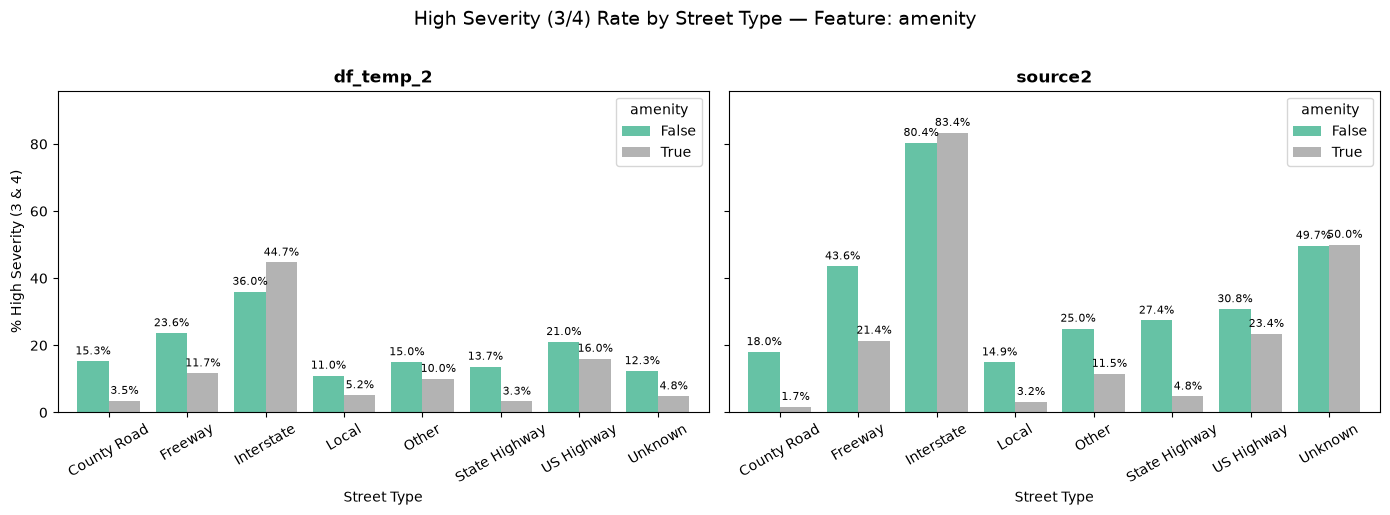

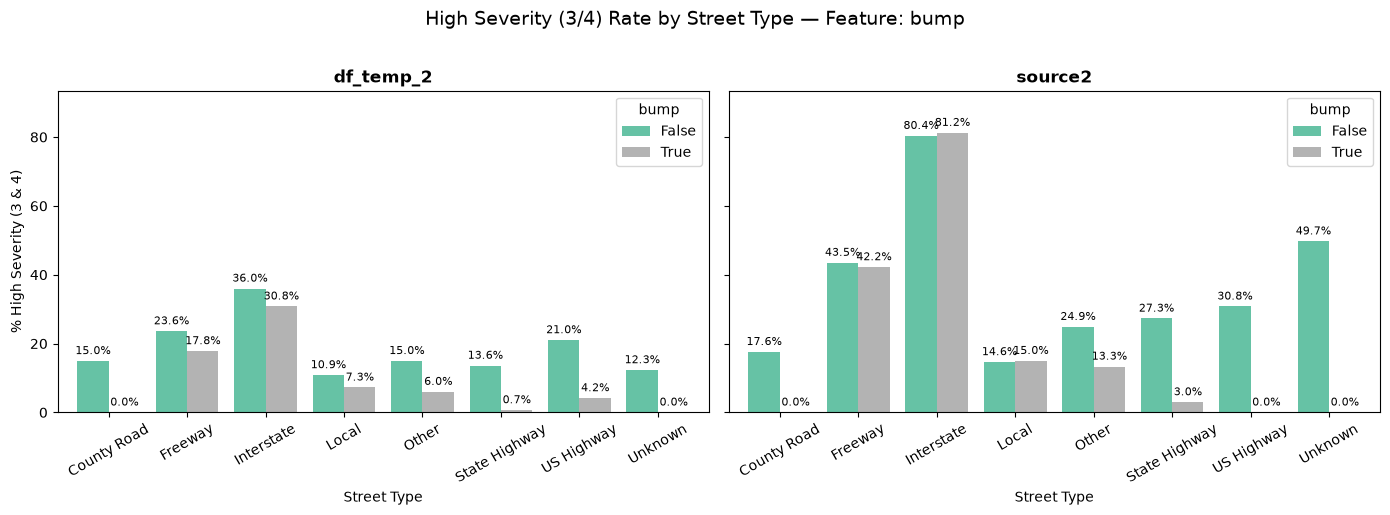

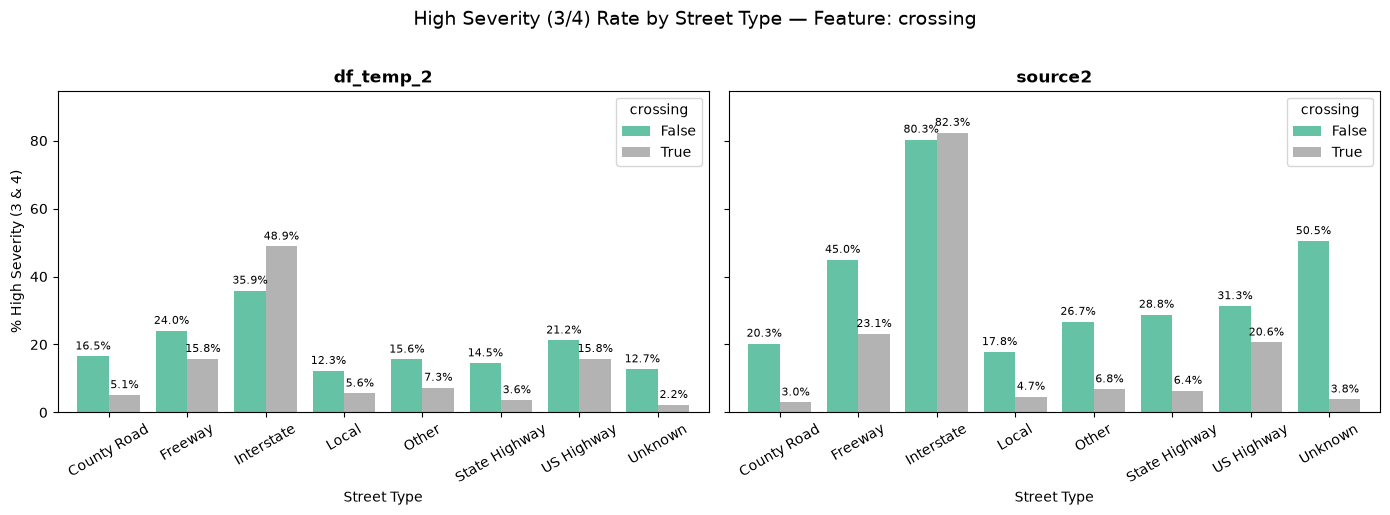

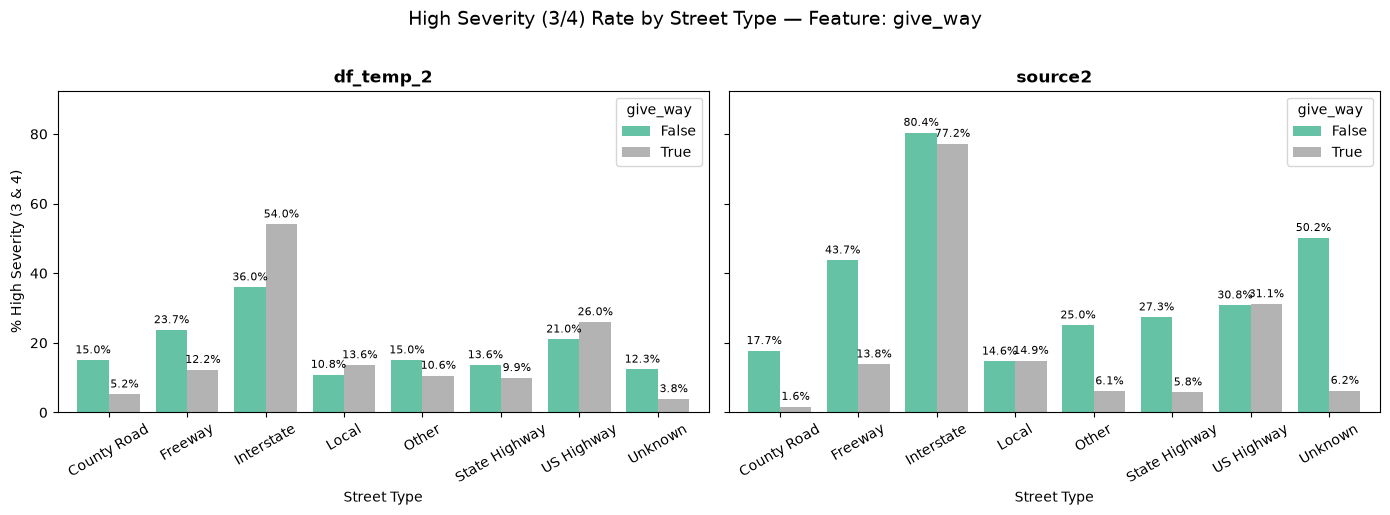

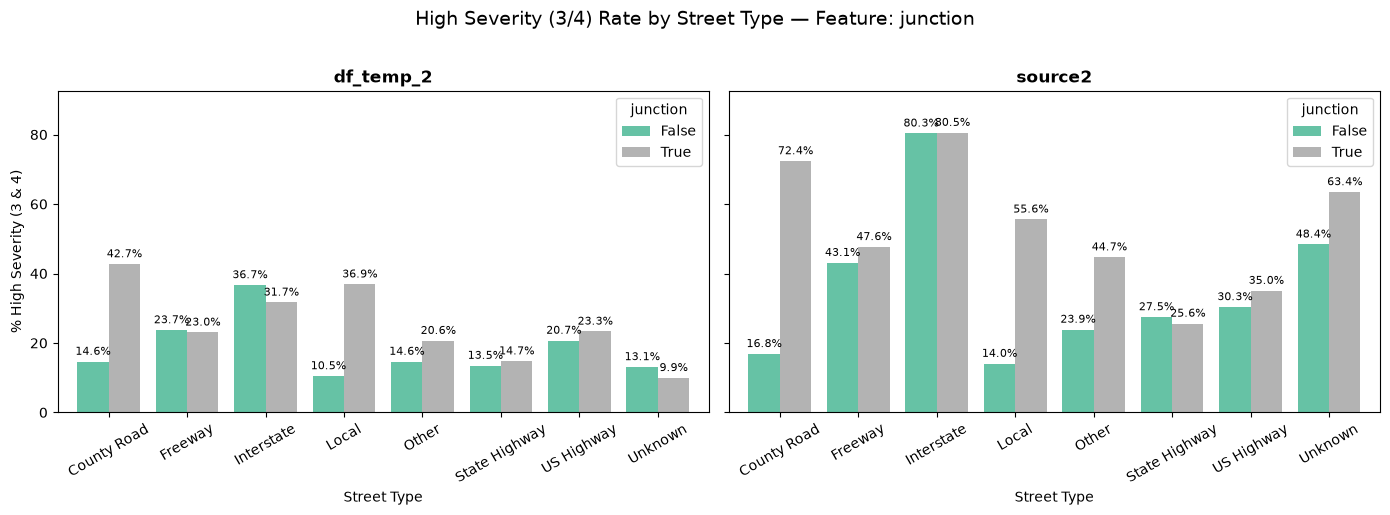

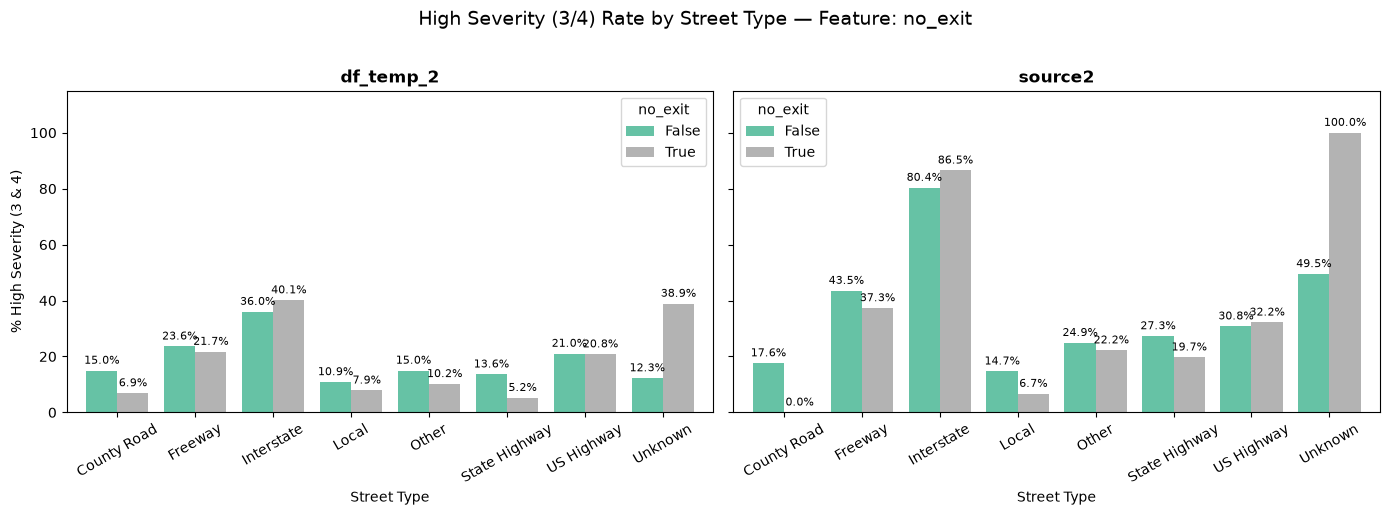

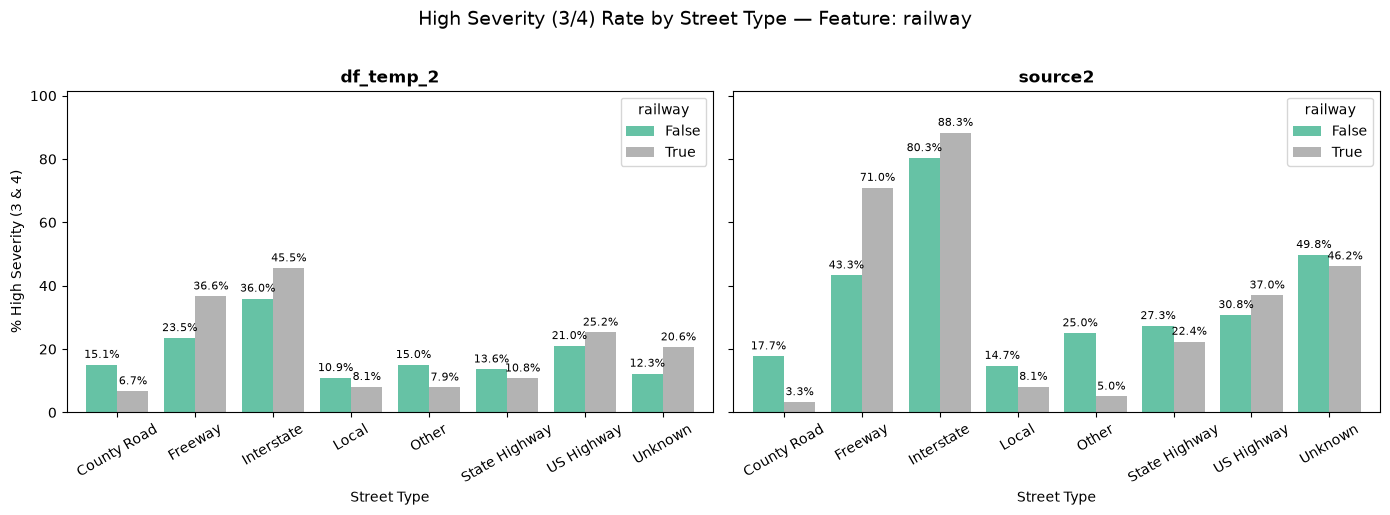

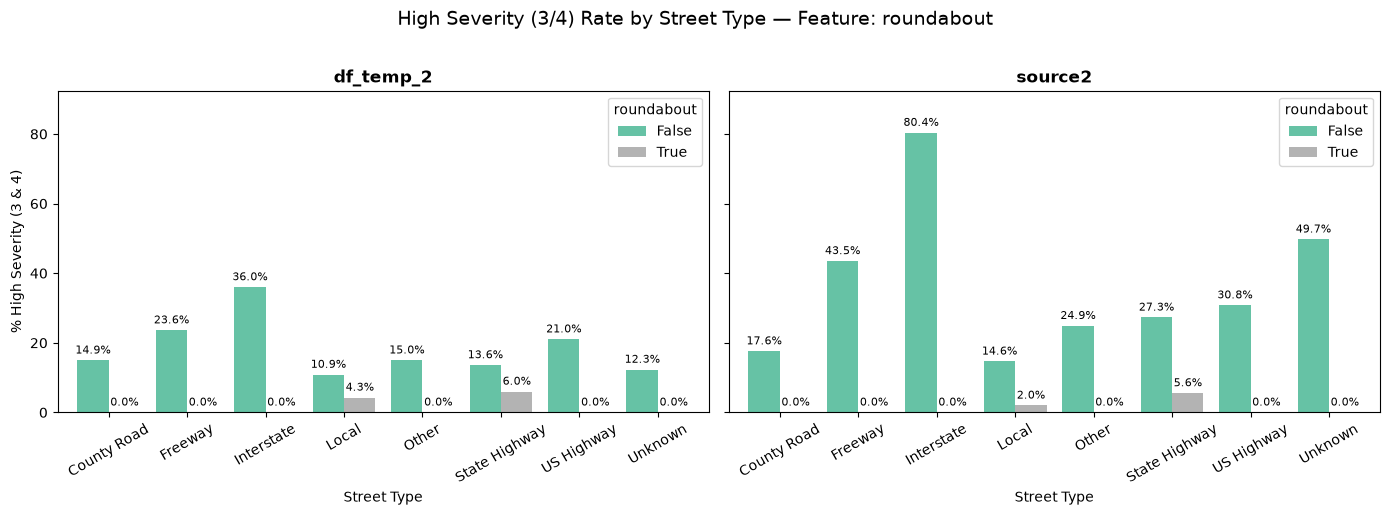

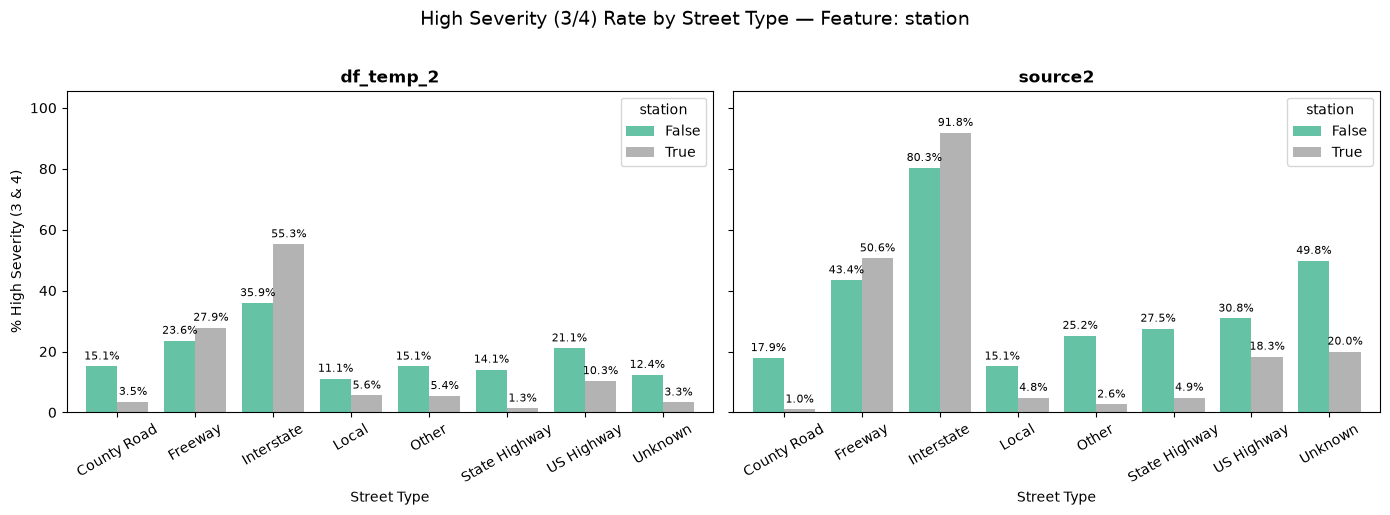

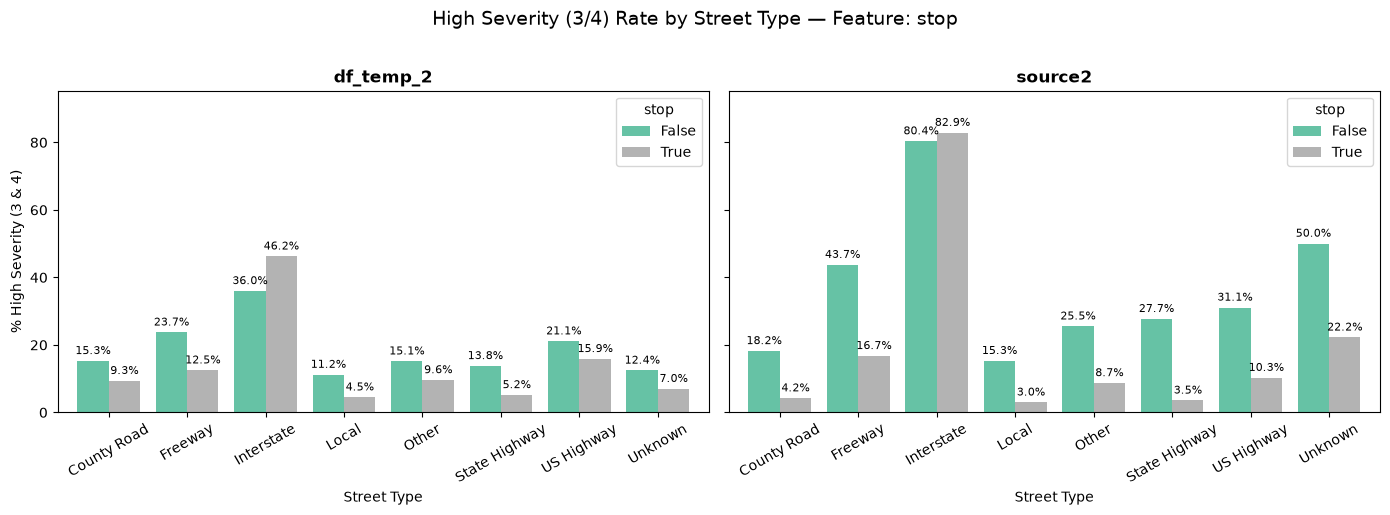

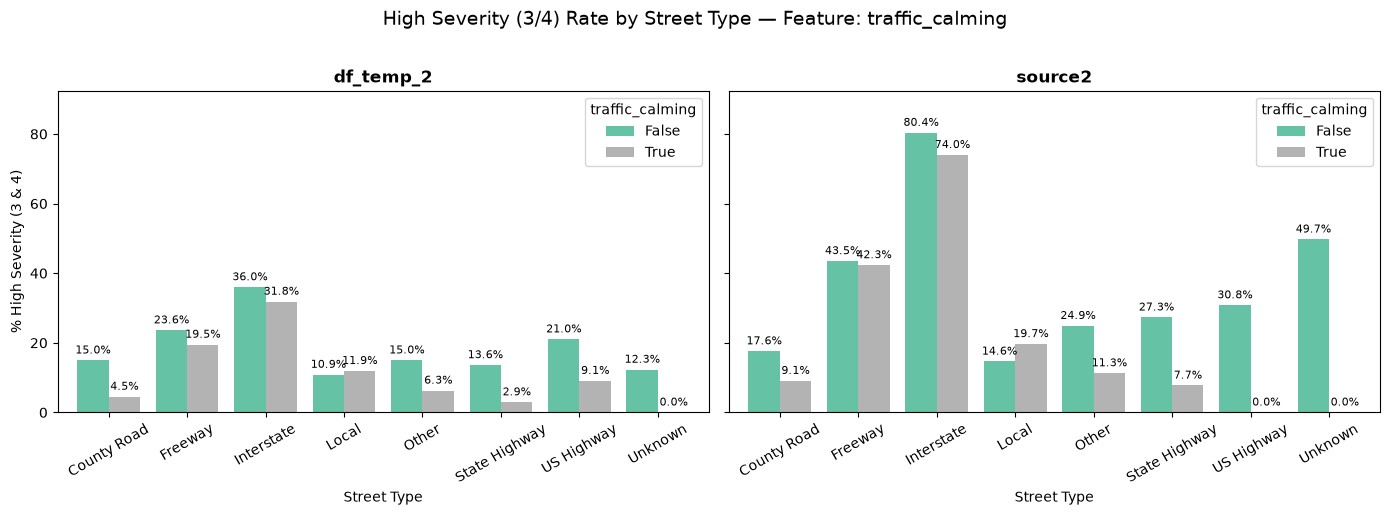

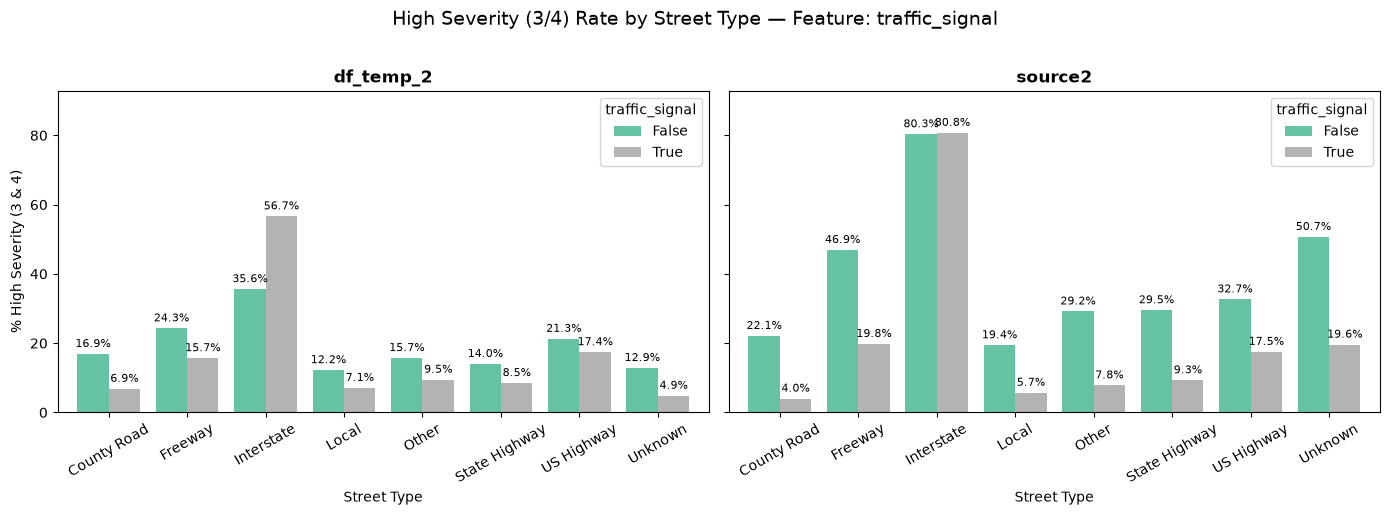

In [136]:
cols = df_temp_2.select_dtypes(include=bool).columns.tolist()
dataset_names = ["df_temp_2", "source2"]
datasets = [df_temp_2, source2]

for feature in cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for idx, (df, name) in enumerate(zip(datasets, dataset_names)):
        ax = axes[idx]

        grouped = (
            df.groupby(["street_type", feature])["severity"]
            .apply(lambda x: x.isin([3, 4]).mean() * 100)
            .unstack(fill_value=0)
        )

        grouped.plot(kind="bar", ax=ax, width=0.8, colormap="Set2")

        ax.set_title(name, fontsize=12, fontweight="bold")
        ax.set_xlabel("Street Type")
        ax.set_ylabel(
            "% High Severity (3 & 4)" if idx == 0 else ""
        )  
        ax.tick_params(axis="x", rotation=30)
        ax.legend(title=feature, labels=["False", "True"])

        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

        max_val = grouped.values.max() if len(grouped) > 0 else 100
        ax.set_ylim(0, max_val * 1.15)

    plt.suptitle(
        f"High Severity (3/4) Rate by Street Type — Feature: {feature}",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

Easier to view all graphs in a numerical tabular format:


In [137]:
cols = df_temp_2.select_dtypes(include=bool).columns.tolist()
datasets = {"df_temp_2": df_temp_2, "source2": source2}

all_results = []

for dataset_name, df in datasets.items():
    for col in cols:
        grouped = (
            df.groupby(["street_type", col])["severity"]
            .agg(
                Count="count",
                Severe_Count=lambda x: x.isin([3, 4]).sum(),
                Pct_Severe=lambda x: x.isin([3, 4]).mean() * 100,
            )
            .reset_index()
        )

        grouped["Dataset"] = dataset_name
        grouped["Road Feature"] = col

        all_results.append(grouped)

giant_table = pd.concat(all_results, ignore_index=True)

giant_table = giant_table.rename(
    columns={
        "street_type": "Street Type",
        col: "Feature Present",
        "Severe_Count": "Severe Count",
        "Pct_Severe": "% Severe",
    }
)
giant_table = giant_table[
    [
        "Dataset",
        "Road Feature",
        "Street Type",
        "Feature Present",
        "Count",
        "Severe Count",
        "% Severe",
    ]
]
giant_table["% Severe"] = giant_table["% Severe"].round(1)

display(giant_table)

,Dataset,Road Feature,Street Type,Feature Present,Count,Severe Count,% Severe
0,df_temp_2,amenity,County Road,NaN,23688,3614,15.3
1,df_temp_2,amenity,County Road,NaN,634,22,3.5
2,df_temp_2,amenity,Freeway,NaN,762507,180327,23.6
3,df_temp_2,amenity,Freeway,NaN,2587,302,11.7
4,df_temp_2,amenity,Interstate,NaN,1936530,696827,36.0
...,...,...,...,...,...,...,...
370,source2,traffic_signal,State Highway,True,27318,2544,9.3
371,source2,traffic_signal,US Highway,False,90474,29562,32.7
372,source2,traffic_signal,US Highway,True,12891,2260,17.5
373,source2,traffic_signal,Unknown,False,1574,798,50.7


## 2.7 Time and light — raw comparison, then split by street_type

- Check how light score affect the Severity 


In [162]:
full_light_sev = df_temp_2.groupby(['light_score'])['severity'].apply(lambda x: x.isin([3,4]).mean() * 100)
source_2_light_sev = source2.groupby('light_score')['severity'].apply(lambda x: x.isin([3,4]).mean()*100)
display(full_light_sev, source_2_light_sev)

# added: same tables with row counts alongside the percentage
full_light_counts = pd.DataFrame({
    'rows': df_temp_2.groupby('light_score').size(),
    'pct_severe': full_light_sev.round(2)
})
source_2_light_counts = pd.DataFrame({
    'rows': source2.groupby('light_score').size(),
    'pct_severe': source_2_light_sev.round(2)
})
display(full_light_counts, source_2_light_counts)


light_score
0.0    19.724199
1.0    19.927017
2.0    19.808501
3.0    20.786369
4.0    17.981767
Name: severity, dtype: float64

light_score
0.0    33.098134
1.0    31.587742
2.0    33.197537
3.0    35.300200
4.0    40.167669
Name: severity, dtype: float64

,rows,pct_severe
light_score,,
0.0,5329053,19.72
1.0,366387,19.93
2.0,380367,19.81
3.0,307769,20.79
4.0,1321572,17.98


,rows,pct_severe
light_score,,
0.0,2437222,33.10
1.0,179538,31.59
2.0,174281,33.20
3.0,134427,35.30
4.0,378364,40.17


- Hour, Weekday, Month - How do different time stamps affect severity

In [163]:
dt_cols = ["start_hour", "start_day", "start_month"]
dataset = [df_temp_2, source2]
for j in dataset:
    for col_name in dt_cols:
        table = (
            j.groupby(col_name)["severity"]
            .apply(lambda x: x.isin([3, 4]).mean() * 100)
            .reset_index(name="high_severity_pct")
            .round(2)
        )

        display(table)

# added: same tables with row counts alongside the percentage
for j in dataset:
    for col_name in dt_cols:
        table_counts = (
            j.groupby(col_name)["severity"]
            .agg(
                rows="size",
                severe_rows=lambda x: x.isin([3, 4]).sum(),
                pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
            )
            .round(2)
        )
        display(table_counts)


,start_hour,high_severity_pct
0,0,15.85
1,1,14.15
2,2,15.76
3,3,17.62
4,4,21.40
5,5,20.06
6,6,20.11
7,7,18.83
8,8,18.99
9,9,20.82


,start_day,high_severity_pct
0,0,19.30
1,1,19.01
2,2,18.87
3,3,18.97
4,4,19.14
5,5,20.99
6,6,22.33


,start_month,high_severity_pct
0,1,16.60
1,2,17.96
2,3,21.21
3,4,20.60
4,5,21.88
5,6,23.47
6,7,22.98
7,8,22.74
8,9,19.38
9,10,19.02


,start_hour,high_severity_pct
0,0,47.72
1,1,46.37
2,2,47.33
3,3,46.17
4,4,30.04
5,5,30.72
6,6,29.15
7,7,25.73
8,8,25.00
9,9,30.83


,start_day,high_severity_pct
0,0,30.66
1,1,30.68
2,2,30.84
3,3,31.52
4,4,32.80
5,5,56.35
6,6,57.18


...

,rows,severe_rows,pct_severe
start_day,,,
0,1210921,233688,19.30
1,1290929,245469,19.01
2,1312389,247629,18.87
3,1316229,249714,18.97
4,1366499,261509,19.14
5,668683,140368,20.99
6,562744,125670,22.33


,rows,severe_rows,pct_severe
start_month,,,
1,751946,124812,16.60
2,658984,118373,17.96
3,554595,117610,21.21
4,587300,120987,20.60
5,558176,122112,21.88
6,571373,134103,23.47
7,512335,117720,22.98
8,599666,136363,22.74
9,651381,126208,19.38


,rows,severe_rows,pct_severe
start_hour,,,
0,15936,7604,47.72
1,14405,6680,46.37
2,15633,7399,47.33
3,15671,7236,46.17
4,86378,25944,30.04
5,108991,33484,30.72
6,222360,64816,29.15
7,351052,90333,25.73
8,357178,89294,25.00


,rows,severe_rows,pct_severe
start_day,,,
0,570495,174887,30.66
1,598997,183747,30.68
2,602320,185743,30.84
3,592191,186638,31.52
4,600632,197006,32.80
5,181721,102394,56.35
6,159017,90920,57.18


,rows,severe_rows,pct_severe
start_month,,,
1,270981,91790,33.87
2,262162,89674,34.21
3,254287,85531,33.64
4,251515,84491,33.59
5,245042,83765,34.18
6,253503,91703,36.17
7,257798,92362,35.83
8,318471,109694,34.44
9,297025,98906,33.30


- hour × street_type x severity
- light_score × street_type x severity

In [164]:
# full dataset
display(df_temp_2.groupby(['start_hour', 'street_type'])['severity'].apply(lambda x: x.isin([3,4]).mean()*100).transpose, 
        df_temp_2.groupby(['light_score', 'street_type'])['severity'].apply(lambda x: x.isin([3,4]).mean()*100).transpose
)

# added: full dataset, unstacked grids with row counts underneath each percentage grid
display(
    df_temp_2.groupby(['start_hour', 'street_type'])['severity']
        .apply(lambda x: x.isin([3, 4]).mean() * 100).unstack().round(2),
    df_temp_2.groupby(['start_hour', 'street_type']).size().unstack(),
    df_temp_2.groupby(['light_score', 'street_type'])['severity']
        .apply(lambda x: x.isin([3, 4]).mean() * 100).unstack().round(2),
    df_temp_2.groupby(['light_score', 'street_type']).size().unstack(),
)


<bound method IndexOpsMixin.transpose of start_hour  street_type  
0           County Road      15.317919
            Freeway          24.406780
            Interstate       20.909148
            Local            11.100983
            Other            13.230256
                               ...    
23          Local            10.476675
            Other            12.859494
            State Highway    11.142222
            US Highway       19.725057
            Unknown           8.441558
Name: severity, Length: 192, dtype: float64>

<bound method IndexOpsMixin.transpose of light_score  street_type  
0.0          County Road      15.381737
             Freeway          23.330253
             Interstate       38.071330
             Local            10.719404
             Other            15.399076
             State Highway    13.460459
             US Highway       21.504709
             Unknown          13.382311
1.0          County Road      12.992126
             Freeway          23.230683
             Interstate       36.918450
             Local            11.042425
             Other            14.603029
             State Highway    14.987291
             US Highway       19.804083
             Unknown          11.447084
2.0          County Road      12.987988
             Freeway          23.672531
             Interstate       36.189117
             Local            11.134112
             Other            14.129209
             State Highway    14.148190
             US Highway       19.738518
            

street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_hour,,,,,,,,
0,15.32,24.41,20.91,11.10,13.23,11.68,18.55,6.30
1,16.13,22.81,19.00,9.65,11.16,9.23,17.06,10.96
2,11.44,25.15,22.02,10.32,11.63,10.67,17.18,7.20
3,17.32,27.52,23.71,11.67,12.80,12.20,20.08,11.64
4,14.75,27.21,38.88,11.51,15.12,15.96,23.63,13.21
5,14.14,23.28,34.77,11.62,14.75,12.57,21.72,11.22
6,13.03,21.86,35.71,11.42,15.11,13.92,20.59,10.08
7,10.56,21.74,38.11,9.73,14.38,13.37,20.06,12.80
8,12.17,23.02,40.81,9.48,15.44,12.91,20.98,15.46


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_hour,,,,,,,,
0,346,12095,31766,41690,11383,10861,3999,238
1,310,10771,27471,35566,9658,9641,3435,219
2,271,10581,26643,33699,9015,9296,3486,236
3,254,10060,24732,28836,8286,8343,3163,189
4,583,16282,41694,66235,15287,14227,5264,280
5,806,26908,62150,85926,21794,22138,8157,303
6,1496,44687,110359,158981,37468,35950,16370,526
7,2149,56417,140811,261083,52528,50652,23168,664
8,1964,54664,128845,272564,48842,48732,21344,621


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
light_score,,,,,,,,
0.0,15.38,23.33,38.07,10.72,15.40,13.46,21.50,13.38
1.0,12.99,23.23,36.92,11.04,14.60,14.99,19.80,11.45
2.0,12.99,23.67,36.19,11.13,14.13,14.15,19.74,9.49
3.0,13.36,25.23,36.80,12.07,15.01,15.27,20.55,10.47
4.0,14.28,24.60,28.46,11.01,13.66,13.18,20.03,10.32


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
light_score,,,,,,,,
0.0,16032,520453,1299445,2297040,481399,509418,198324,6942
1.0,1270,35720,94102,152385,34801,33048,14598,463
2.0,1332,37854,98817,154103,37242,35630,14915,474
3.0,1055,32134,79994,123057,30696,28731,11720,382
4.0,4453,137110,359212,510536,130873,127459,49498,2431


In [165]:
# source2 dataset
display(source2.groupby(['start_hour', 'street_type'])['severity'].apply(lambda x: x.isin([3,4]).sum()).transpose().unstack(), 
        source2.groupby(['light_score', 'street_type'])['severity'].apply(lambda x: x.isin([3,4]).sum()).transpose().unstack()
)

# added: source2, percentage grid plus the matching row-count grid
display(
    source2.groupby(['start_hour', 'street_type'])['severity']
        .apply(lambda x: x.isin([3, 4]).mean() * 100).unstack().round(2),
    source2.groupby(['start_hour', 'street_type']).size().unstack(),
    source2.groupby(['light_score', 'street_type'])['severity']
        .apply(lambda x: x.isin([3, 4]).mean() * 100).unstack().round(2),
    source2.groupby(['light_score', 'street_type']).size().unstack(),
)


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_hour,,,,,,,,
0,6,1785,3605,1598,267,282,55,6
1,9,1573,2952,1589,222,249,82,4
2,5,1728,3444,1602,251,290,76,3
3,7,1653,3329,1563,280,326,69,9
4,64,3287,13321,5552,1493,1576,633,18
5,69,4502,17238,6993,2009,1763,891,19
6,134,7632,33465,13985,3936,3559,2068,37
7,146,9730,46677,20091,5486,5116,3027,60
8,151,10095,45815,20301,5279,4704,2884,65


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
light_score,,,,,,,,
0.0,1451,93747,416960,175098,47137,47742,23897,643
1.0,109,6409,29371,12268,3288,3493,1750,24
2.0,108,6897,29933,12342,3409,3497,1644,27
3.0,83,6155,24228,10078,2786,2903,1197,23
4.0,241,23638,75658,32389,7668,9012,3291,83


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_hour,,,,,,,,
0,37.50,57.25,85.92,28.43,29.47,17.10,13.22,42.86
1,75.00,57.16,80.66,29.82,29.56,16.66,20.35,100.00
2,41.67,56.16,82.55,29.60,31.57,17.32,15.87,27.27
3,31.82,56.55,79.89,27.38,31.57,21.22,16.71,60.00
4,16.33,40.60,69.13,13.08,20.08,25.00,26.71,28.12
5,14.05,40.69,69.62,13.63,21.03,20.77,27.26,31.67
6,12.77,36.51,68.82,12.86,20.65,21.67,27.61,35.24
7,9.56,32.61,68.71,10.70,19.21,21.40,26.75,34.29
8,11.29,32.80,69.31,10.24,19.88,20.01,27.65,34.76


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_hour,,,,,,,,
0,16,3118,4196,5621,906,1649,416,14
1,12,2752,3660,5328,751,1495,403,4
2,12,3077,4172,5413,795,1674,479,11
3,22,2923,4167,5708,887,1536,413,15
4,392,8097,19270,42444,7437,6304,2370,64
5,491,11064,24759,51304,9555,8489,3269,60
6,1049,20902,48624,108710,19060,16421,7489,105
7,1527,29842,67932,187790,28557,23911,11318,175
8,1337,30777,66098,198285,26551,23512,10431,187


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
light_score,,,,,,,,
0.0,17.74,42.27,80.80,14.02,24.76,27.32,31.53,51.19
1.0,15.24,39.86,75.41,13.64,22.88,25.89,29.51,34.29
2.0,15.63,42.32,76.65,14.63,23.39,25.88,28.72,48.21
3.0,15.84,45.64,78.23,15.87,24.78,27.79,28.68,37.10
4.0,19.84,50.40,82.33,19.44,27.53,28.11,28.23,51.23


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
light_score,,,,,,,,
0.0,8179,221776,516052,1249033,190408,174730,75788,1256
1.0,715,16080,38948,89931,14371,13492,5931,70
2.0,691,16299,39052,84373,14576,13510,5724,56
3.0,524,13487,30970,63523,11242,10446,4173,62
4.0,1215,46901,91898,166613,27856,32061,11658,162


## 2.8 State

- How do states alter in severity 

,state,AL,high_severity_pct
6,CA,False,1456117
16,FL,False,762978
82,TX,False,455185
76,SC,False,336992
50,NC,False,298205
...,...,...,...
39,ME,True,435
89,VT,True,307
78,SD,False,221
79,SD,True,68


,state,AL,high_severity_pct
6,CA,False,1456117
16,FL,False,762978
82,TX,False,455185
76,SC,False,336992
50,NC,False,298205
...,...,...,...
39,ME,True,435
89,VT,True,307
78,SD,False,221
79,SD,True,68


,state,level_1,high_severity_pct
6,CA,False,352340
82,TX,False,255833
7,CA,True,234527
76,SC,False,188087
16,FL,False,184374
...,...,...,...
52,ND,True,13
78,SD,False,10
49,MT,False,9
53,ND,False,5


,state,level_1,high_severity_pct
6,CA,False,352340
82,TX,False,255833
7,CA,True,234527
76,SC,False,188087
16,FL,False,184374
...,...,...,...
52,ND,True,13
78,SD,False,10
49,MT,False,9
53,ND,False,5


,rows,severe_rows,pct_severe
state,,,
RI,16971,7847,46.24
GA,169234,74021,43.74
KY,32254,13708,42.50
WI,34688,13068,37.67
CO,90885,33810,37.20
IL,168958,62065,36.73
MO,77323,28287,36.58
IA,26307,9023,34.30
VT,926,307,33.15


,rows,severe_rows,pct_severe
state,,,
MT,56,47,83.93
WY,202,166,82.18
WV,442,339,76.70
ND,18,13,72.22
KS,5928,4254,71.76
MO,30919,21609,69.89
CT,22064,14000,63.45
ME,477,296,62.05
RI,11614,7094,61.08


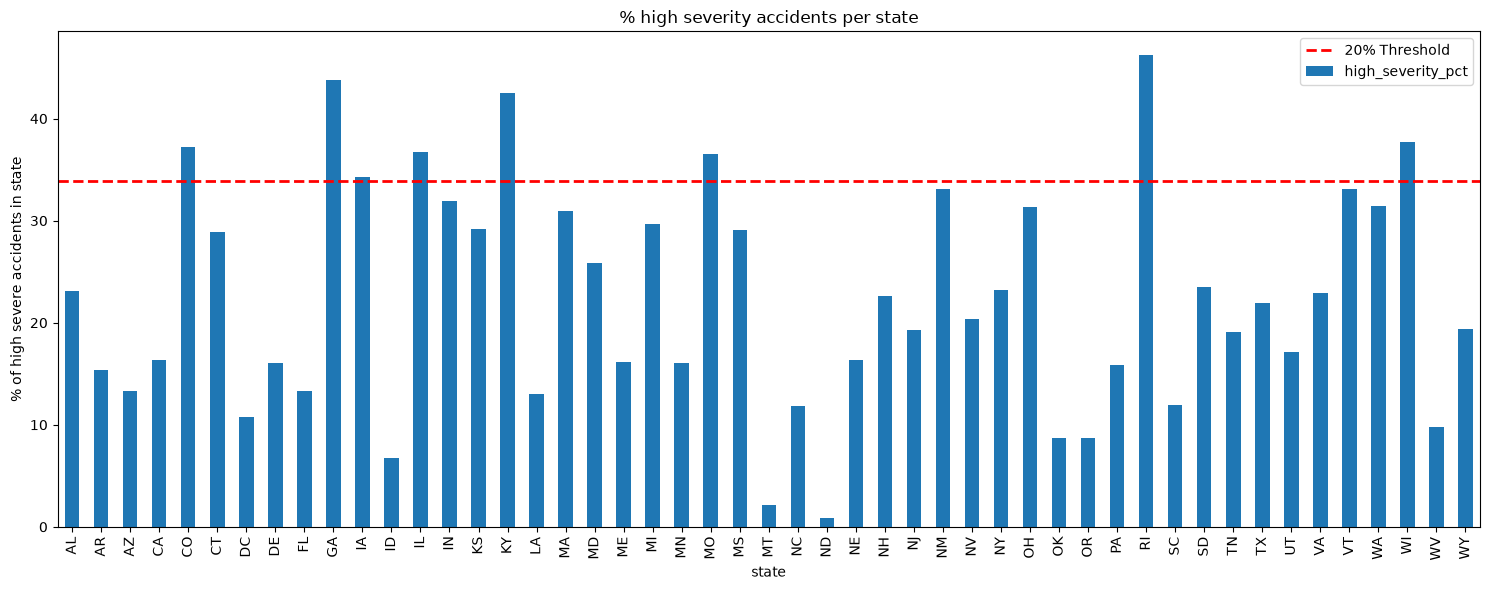

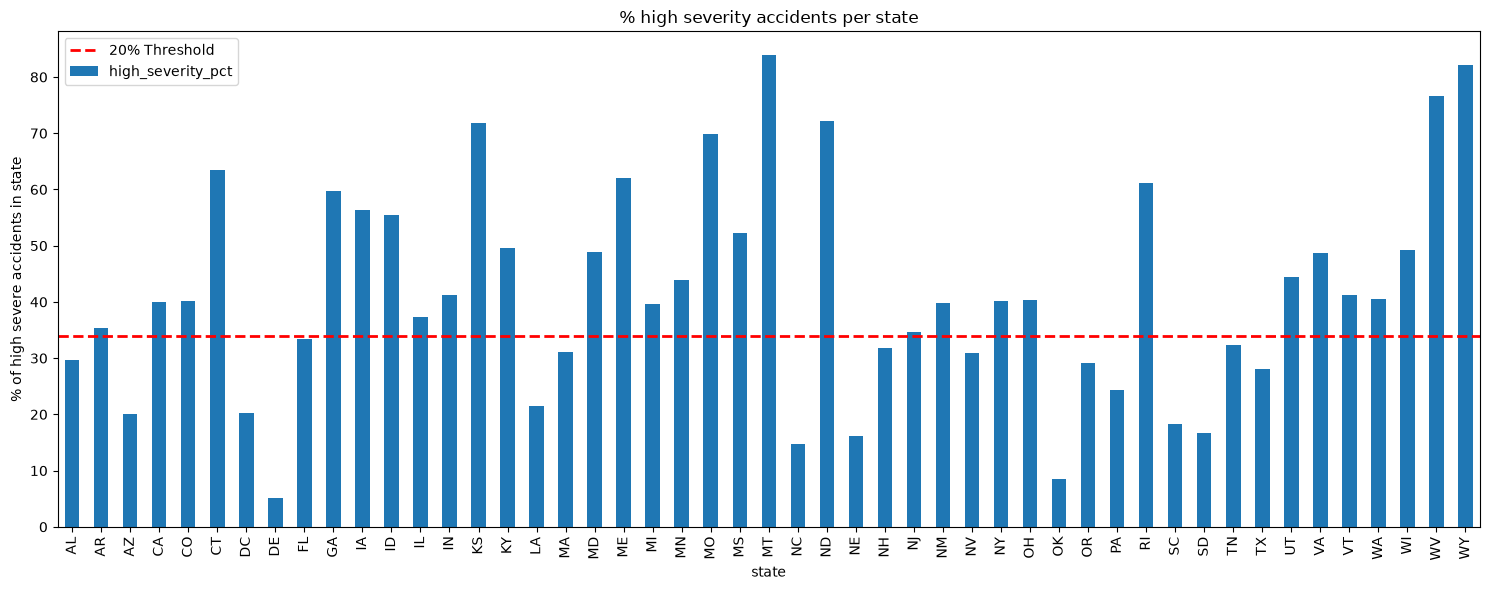

In [142]:
dataset = [df_temp_2, source2]
for j in dataset:
    state_counts = (
        j.groupby('state')['severity']
        .apply(lambda x: x.isin([3, 4]).value_counts())
        .round(2)
        .reset_index(name='high_severity_pct')
    )

    state_counts = state_counts.sort_values(by='high_severity_pct', ascending=False)
    display(state_counts)
    state_counts_2 = (
            j.groupby('state')['severity']
            .apply(lambda x: x.isin([3, 4]).mean()*100)
            .round(2)
            .reset_index(name='high_severity_pct')
        )
    state_counts_2.plot(x = 'state', y = 'high_severity_pct', kind = 'bar',  figsize = (15,6))
    plt.axhline(y = 33.92, color = 'red', linestyle='--', linewidth=2, label='20% Threshold')
    plt.xlabel('state')
    plt.ylabel('% of high severe accidents in state')
    plt.title('% high severity accidents per state')
    plt.legend()
    plt.tight_layout()
    display(state_counts)

# added: state table with row counts alongside the percentage
for j in dataset:
    state_with_counts = (
        j.groupby('state')['severity']
        .agg(
            rows='size',
            severe_rows=lambda x: x.isin([3, 4]).sum(),
            pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
        )
        .round(2)
        .sort_values(by='pct_severe', ascending=False)
    )
    display(state_with_counts)


# Step 2 — additional checks

Added after the first pass. Each one answers a question left open above.

1. `start_day` split by `street_type` — does the weekend effect survive?
2. Do the six surviving road features overlap each other?
3. Are local-road `junction` accidents really slip roads?
4. State table filtered to states with 10,000+ rows
5. All four severity levels against `street_type`
6. Seven weather flag columns, built and tested

### 1. `start_day` × `street_type` × severity

Weekends showed 56–57% severe against ~31% on weekdays in Source2, versus a
3-point effect on the full dataset. Same test as `start_hour`: hold road type
fixed and see whether the gap is still there. 0 = Monday, 6 = Sunday.

In [143]:
# full dataset
display(
    df_temp_2.groupby(['start_day', 'street_type'])['severity']
        .apply(lambda x: x.isin([3, 4]).mean() * 100).unstack().round(2),
    df_temp_2.groupby(['start_day', 'street_type']).size().unstack(),
)

street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_day,,,,,,,,
0,14.70,23.47,37.25,10.50,15.28,13.68,21.01,12.48
1,13.78,22.72,36.66,10.40,15.21,13.20,20.91,12.62
2,14.02,22.58,36.39,10.29,14.84,12.94,20.45,13.17
3,13.66,22.87,35.92,10.42,14.75,12.91,20.54,12.20
4,15.89,23.14,35.98,10.47,14.86,13.31,21.12,11.71
5,17.21,26.05,34.05,13.05,14.48,14.65,22.38,11.50
6,18.57,27.65,34.15,14.36,15.39,16.79,21.85,12.32


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_day,,,,,,,,
0,3872,117926,289474,529594,110388,113193,44912,1562
1,4078,126589,309466,561519,115930,122803,48904,1640
2,4216,128321,317173,566633,119070,125418,49888,1670
3,4042,128605,325768,560591,119984,126035,49441,1763
4,4330,132251,340415,583124,124159,129060,51384,1776
5,2104,70954,187694,244973,69023,67683,24922,1330
6,1680,60448,168245,198356,59241,52421,21225,1128


In [144]:
# source2 dataset
display(
    source2.groupby(['start_day', 'street_type'])['severity']
        .apply(lambda x: x.isin([3, 4]).mean() * 100).unstack().round(2),
    source2.groupby(['start_day', 'street_type']).size().unstack(),
)

street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_day,,,,,,,,
0,16.55,40.82,77.94,12.80,22.97,25.56,29.29,42.26
1,14.88,40.41,78.00,12.79,22.96,25.41,29.62,45.00
2,13.72,40.28,78.16,12.91,22.61,25.06,29.04,51.71
3,15.71,41.33,78.48,13.21,23.03,25.29,29.84,46.65
4,19.00,42.54,79.96,13.83,24.65,27.15,30.94,50.00
5,37.50,57.29,90.18,35.44,38.83,36.66,38.93,65.42
6,39.64,57.57,91.13,36.05,38.79,38.49,38.39,68.27


street_type,County Road,Freeway,Interstate,Local,Other,State Highway,US Highway,Unknown
start_day,,,,,,,,
0,2066,51475,114840,299956,44662,39909,17322,265
1,2157,53852,121018,314188,46401,42665,18436,280
2,2164,54510,122716,313259,47405,43232,18742,292
3,2012,53836,123161,305665,46193,42828,18183,313
4,2116,54356,127258,308352,46758,42828,18700,264
5,432,24839,57726,60071,14135,17899,6512,107
6,386,21817,50843,52423,13015,14959,5470,104


In [145]:
# weekday vs weekend collapsed, per street type — easier to read than seven columns
for name, j in {'df_temp_2': df_temp_2, 'source2': source2}.items():
    is_weekend = j['start_day'].isin([5, 6])
    table = (
        j.groupby(['street_type', is_weekend.rename('weekend')])['severity']
        .agg(
            rows='size',
            pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
        )
        .round(2)
        .unstack()
    )
    print(name)
    display(table)

df_temp_2


rows         pct_severe       
weekend          False   True       False  True 
street_type                                     
County Road      20538    3784      14.42  17.81
Freeway         633692  131402      22.95  26.79
Interstate     1582296  355939      36.42  34.10
Local          2801461  443329      10.42  13.64
Other           589531  128264      14.98  14.90
State Highway   616509  120104      13.20  15.59
US Highway      244529   46147      20.80  22.13
Unknown           8411    2458      12.42  11.88

source2


rows         pct_severe       
weekend          False   True       False  True 
street_type                                     
County Road      10515     818      15.96  38.51
Freeway         268029   46656      41.08  57.42
Interstate      608993  108569      78.53  90.63
Local          1541420  112494      13.11  35.72
Other           231419   27150      23.24  38.81
State Highway   211462   32858      25.69  37.49
US Highway       91383   11982      29.75  38.68
Unknown           1414     211      47.17  66.82

### 2. Do the six surviving road features overlap each other?

`traffic_signal`, `crossing`, `stop`, `amenity`, `roundabout` and `station` all
survived the `street_type` split, and all point the same way. They may not be
six separate facts — one town-centre junction can carry a light, a crossing, a
stop sign, a shop and a bus stop at once, so five columns would be True for the
same accident.

Two views below:

- correlation matrix — how closely each pair moves together
- conditional table — of the rows where the row feature is True, what
  percentage also have the column feature True

High numbers mean near-duplicates: keep one, or replace the set with a single
count of how many are True.

In [146]:
constrained = ['traffic_signal', 'crossing', 'stop', 'amenity', 'roundabout', 'station']

# how often each feature is True at all, for context
display(
    pd.DataFrame({
        'true_rows': source2[constrained].sum(),
        'pct_true': (source2[constrained].mean() * 100).round(2),
    })
)

# correlation between the six boolean columns
display(source2[constrained].astype(int).corr().round(2))

,true_rows,pct_true
traffic_signal,734949,22.23
crossing,475637,14.39
stop,105840,3.20
amenity,48391,1.46
roundabout,125,0.00
station,87390,2.64


,traffic_signal,crossing,stop,amenity,roundabout,station
traffic_signal,1.00,0.49,-0.07,0.11,-0.0,0.13
crossing,0.49,1.00,0.10,0.16,0.0,0.17
stop,-0.07,0.10,1.00,0.04,0.0,0.03
amenity,0.11,0.16,0.04,1.00,-0.0,0.18
roundabout,-0.00,0.00,0.00,-0.00,1.0,-0.00
station,0.13,0.17,0.03,0.18,-0.0,1.00


In [147]:
# P(column is True | row is True), as a percentage
overlap = pd.DataFrame(index=constrained, columns=constrained, dtype=float)

for a in constrained:
    subset = source2.loc[source2[a], constrained]
    overlap.loc[a] = (subset.mean() * 100).round(1)

display(overlap)

,traffic_signal,crossing,stop,amenity,roundabout,station
traffic_signal,100.0,46.9,0.8,3.9,0.0,6.7
crossing,72.4,100.0,7.4,6.1,0.0,9.2
stop,5.5,33.1,100.0,4.0,0.0,5.6
amenity,59.0,59.9,8.8,100.0,0.0,26.3
roundabout,0.8,16.0,10.4,0.8,100.0,0.8
station,56.0,50.2,6.7,14.6,0.0,100.0


### 3. Are local-road `junction` accidents really slip roads?

`junction` is the largest effect found anywhere: on local roads, 14.05% severe
without it against 56.07% with it.

OpenStreetMap's junction tag covers motorway slip roads and interchanges as
well as street corners. If `street_type_shift` failed to classify some ramps as
highways, those rows sit in Local while behaving like Interstate — which would
inflate the 56%.

Read the raw `street` values below. Names like "I-95 N", "Exit 24" or "Ramp"
mean misclassification. Ordinary street names mean the effect is real.

In [148]:
# how many of the six are True at once, and does that count track severity?
source2_constraint_count = source2[constrained].sum(axis=1)

display(
    source2.groupby(source2_constraint_count.rename('n_constraint_features'))['severity']
    .agg(
        rows='size',
        pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
    )
    .round(2)
)

# same thing within local roads only, so street_type is held fixed
local = source2[source2.street_type == 'Local']
display(
    local.groupby(local[constrained].sum(axis=1).rename('n_constraint_features'))['severity']
    .agg(
        rows='size',
        pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
    )
    .round(2)
)

,rows,pct_severe
n_constraint_features,,
0,2335258,44.14
1,555381,11.55
2,356010,6.70
3,50056,4.91
4,8577,1.76
5,91,0.00


,rows,pct_severe
n_constraint_features,,
0,886932,22.48
1,418412,6.83
2,295529,4.24
3,45069,3.61
4,7894,1.52
5,78,0.00


In [149]:
junction_local = source2[(source2.street_type == 'Local') & (source2.junction)]

print('local + junction rows:', len(junction_local))
print('pct severe:', round(junction_local.severity.isin([3, 4]).mean() * 100, 2))

# most common raw street names in that group
display(junction_local.street.value_counts().head(30))

# a random sample of individual rows
display(junction_local[['street', 'state', 'severity']].sample(30, random_state=42))

local + junction rows: 24974
pct severe: 55.58


street
S La Brea Ave         378
Skirball Center Dr    333
Fairfield Rd          270
Arlington Ave         261
Main St               239
Saint Andrews Rd      229
Tuckahoe Rd           225
Cross River Rd        219
W W.T. Harris Blvd    214
FDR Dr S              211
N Jim Miller Rd       207
Haywood Ln            202
Glades Rd             187
W Hillsboro Blvd      185
White Horse Rd        184
Georgia Ave           179
S La Cienega Blvd     170
Roosevelt Blvd        164
Fingerboard Rd        159
Fruitridge Rd         155
Duke St               154
E 51st St             154
Lankershim Blvd       150
Rock Quarry Rd        150
S Congress Ave        145
S Garfield Ave        144
New Hampshire Ave     141
E Sibley Blvd         135
Harbison Blvd         133
Northampton Blvd      133
Name: count, dtype: int64

,street,state,severity
index,,,
2633424,Charlotte Ave,TN,3
2802222,Falls of Neuse Rd,NC,2
228401,Diley Rd,OH,2
2087217,Skirball Center Dr,CA,3
1094080,Skirball Center Dr,CA,3
2300658,Louise St,LA,2
2275976,Castle Ridge Rd,TX,2
484890,S Ewing Ave,TX,3
252638,Annapolis Rd,MD,2


In [150]:
# how many of those street names look like highway or ramp names?
ramp_pattern = r'\bi[-\s]?\d+|\binterstate\b|\bramp\b|\bexit\b|\bon[-\s]?ramp\b|\boff[-\s]?ramp\b|\bhwy\b|\bfwy\b|\bexpy\b'

looks_like_ramp = junction_local.street.astype(str).str.lower().str.contains(
    ramp_pattern, na=False, regex=True
)

print('share of local+junction rows with highway/ramp wording:',
      round(looks_like_ramp.mean() * 100, 2), '%')

display(
    junction_local.groupby(looks_like_ramp.rename('looks_like_ramp'))['severity']
    .agg(
        rows='size',
        pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
    )
    .round(2)
)

share of local+junction rows with highway/ramp wording: 0.01 %


,rows,pct_severe
looks_like_ramp,,
False,24971,55.58
True,3,0.00


### 4. State table, filtered to states with 10,000+ rows

The unfiltered ranking is topped by states with almost no data — North Dakota
at 72.22% is 13 severe accidents out of 18, Montana and South Dakota similar.
Anything below a few thousand rows is noise.

In [151]:
min_rows = 10000

for name, j in {'df_temp_2': df_temp_2, 'source2': source2}.items():
    state_table = (
        j.groupby('state')['severity']
        .agg(
            rows='size',
            severe_rows=lambda x: x.isin([3, 4]).sum(),
            pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
        )
        .round(2)
    )

    dropped = state_table[state_table.rows < min_rows]
    kept = state_table[state_table.rows >= min_rows].sort_values('pct_severe', ascending=False)

    print(f'{name}: {len(kept)} states kept, {len(dropped)} dropped for having under {min_rows} rows')
    display(kept)
    display(dropped.sort_values('rows'))

df_temp_2: 44 states kept, 5 dropped for having under 10000 rows


,rows,severe_rows,pct_severe
state,,,
RI,16971,7847,46.24
GA,169234,74021,43.74
KY,32254,13708,42.50
WI,34688,13068,37.67
CO,90885,33810,37.20
IL,168958,62065,36.73
MO,77323,28287,36.58
IA,26307,9023,34.30
NM,10325,3422,33.14


,rows,severe_rows,pct_severe
state,,,
SD,289,68,23.53
VT,926,307,33.15
ME,2698,435,16.12
ND,3487,31,0.89
WY,3757,729,19.40


source2: 34 states kept, 15 dropped for having under 10000 rows


,rows,severe_rows,pct_severe
state,,,
MO,30919,21609,69.89
CT,22064,14000,63.45
RI,11614,7094,61.08
GA,93311,55746,59.74
IA,11640,6550,56.27
KY,24192,11984,49.54
WI,16962,8357,49.27
MD,41321,20194,48.87
VA,97042,47302,48.74


,rows,severe_rows,pct_severe
state,,,
SD,12,2,16.67
ND,18,13,72.22
MT,56,47,83.93
WY,202,166,82.18
ID,229,127,55.46
WV,442,339,76.70
ME,477,296,62.05
VT,554,228,41.16
AR,1406,498,35.42


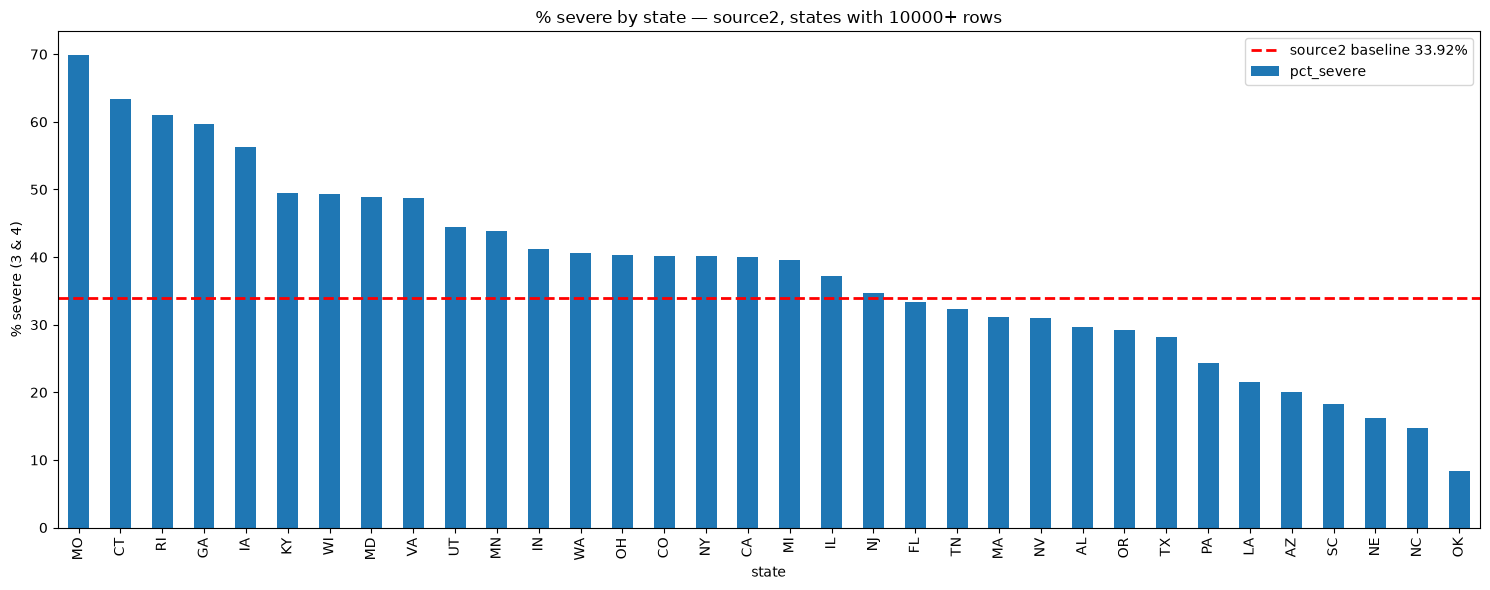

In [152]:
# plot the filtered source2 states against the source2 baseline
source2_baseline = source2.severity.isin([3, 4]).mean() * 100

state_table_s2 = (
    source2.groupby('state')['severity']
    .agg(
        rows='size',
        pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
    )
    .round(2)
)
state_table_s2 = state_table_s2[state_table_s2.rows >= min_rows].sort_values(
    'pct_severe', ascending=False
)

state_table_s2.pct_severe.plot(kind='bar', figsize=(15, 6))
plt.axhline(
    y=source2_baseline, color='red', linestyle='--', linewidth=2,
    label=f'source2 baseline {source2_baseline:.2f}%'
)
plt.xlabel('state')
plt.ylabel('% severe (3 & 4)')
plt.title(f'% severe by state — source2, states with {min_rows}+ rows')
plt.legend()
plt.tight_layout()
plt.show()

### 5. All four severity levels against `street_type`

Everything so far collapses severity into severe (3 or 4) and not severe
(1 or 2). This checks whether that binary is hiding anything — in particular
whether the 80% on Interstates is almost all 3s, or whether the share of 4s
rises too.

Rows sum to 100% within each street type.

In [153]:
for name, j in {'df_temp_2': df_temp_2, 'source2': source2}.items():
    print(name)
    display(
        pd.crosstab(j.street_type, j.severity, normalize='index').mul(100).round(2)
    )
    display(pd.crosstab(j.street_type, j.severity))

df_temp_2


severity,1,2,3,4
street_type,,,,
County Road,0.88,84.17,9.03,5.92
Freeway,0.45,75.95,21.84,1.77
Interstate,0.35,63.65,33.47,2.52
Local,1.40,87.74,8.57,2.29
Other,0.80,84.23,10.68,4.29
State Highway,0.53,85.89,10.92,2.67
US Highway,0.53,78.45,15.60,5.41
Unknown,1.19,86.51,7.67,4.63


severity,1,2,3,4
street_type,,,,
County Road,213,20473,2196,1440
Freeway,3412,581053,167099,13530
Interstate,6880,1233766,648681,48908
Local,45575,2846979,278091,74145
Other,5742,604616,76634,30803
State Highway,3872,632646,80445,19650
US Highway,1543,228045,45357,15731
Unknown,129,9403,834,503


source2


severity,1,2,3,4
street_type,,,,
County Road,1.45,80.97,17.19,0.40
Freeway,0.52,55.98,43.21,0.30
Interstate,0.26,19.39,79.23,1.13
Local,1.55,83.80,14.50,0.14
Other,1.10,74.02,24.54,0.34
State Highway,0.74,71.98,26.60,0.68
US Highway,0.92,68.30,30.52,0.27
Unknown,7.32,42.95,48.92,0.80


severity,1,2,3,4
street_type,,,,
County Road,164,9176,1948,45
Freeway,1627,176168,135960,930
Interstate,1839,139110,568499,8114
Local,25700,1385988,239863,2363
Other,2849,191389,63458,873
State Highway,1815,175853,64993,1659
US Highway,947,70596,31546,276
Unknown,119,698,795,13


In [154]:
# same check for the other strong features, source2 only
for col in ['junction', 'traffic_signal']:
    print(col)
    display(
        pd.crosstab(source2[col], source2.severity, normalize='index').mul(100).round(2)
    )

# and across the hour of day
display(
    pd.crosstab(source2.start_hour, source2.severity, normalize='index').mul(100).round(2)
)

junction


severity,1,2,3,4
junction,,,,
False,1.10,66.26,32.21,0.43
True,0.35,41.55,57.55,0.55


traffic_signal


severity,1,2,3,4
traffic_signal,,,,
False,0.89,58.13,40.44,0.54
True,1.65,89.09,9.20,0.06


severity,1,2,3,4
start_hour,,,,
0,0.40,51.89,46.25,1.46
1,0.17,53.46,44.82,1.56
2,1.22,51.46,45.71,1.62
3,1.13,52.70,44.63,1.54
4,2.47,67.50,29.10,0.93
5,1.97,67.30,30.12,0.60
6,1.84,69.01,28.80,0.35
7,1.97,72.30,25.49,0.25
8,1.95,73.05,24.80,0.20


### 6. Seven weather flag columns

The keyword loop above searches the raw text one word at a time. Three problems
with it: `'snow'` misses "wintry mix" and "flurries", `'rain'` misses "drizzle"
and "showers", and "clear" and "fair" are tested separately even though they
mean the same sky.

These flags fix all three. Each is 0/1 and a row can set several at once —
"blowing dust / windy" sets both `is_obscured` and `is_windy`, which is correct.
There is no `is_clear` flag: clear weather is every flag at 0, so the clear/fair
wording problem cannot recur.

`intensity` is ordinal: light = 0, unstated = 1, heavy = 2.

Built on both datasets so the two can be compared.

In [155]:
weather_flags = {
    'is_rain':     r'rain|drizzle|shower',
    'is_snow':     r'snow|wintry|flurr',
    'is_ice':      r'ice|icy|sleet|hail|freezing|pellet',
    'is_thunder':  r'thunder|t-storm|tstorm|squall|tornado|funnel',
    'is_fog':      r'fog|mist',
    'is_obscured': r'haze|smoke|dust|sand|ash',
    'is_windy':    r'windy|blowing|drifting|whirl',
}


def add_weather_flags(df, column_name='weather_condition'):
    s = df[column_name].astype(str).str.lower().str.strip()

    out = pd.DataFrame(index=df.index)
    for flag, pattern in weather_flags.items():
        out[flag] = s.str.contains(pattern, na=False, regex=True).astype(int)

    # intensity: light = 0, nothing stated = 1, heavy = 2
    intensity = pd.Series(1, index=df.index)
    intensity[s.str.contains(r'light|shallow|patches', na=False, regex=True)] = 0
    intensity[s.str.contains(r'heavy', na=False, regex=True)] = 2
    out['intensity'] = intensity

    # weather text missing entirely — flags are 0 but that is not "clear"
    out['weather_missing'] = df[column_name].isna().astype(int)

    return out


flag_cols = list(weather_flags.keys())

df_temp_2[flag_cols + ['intensity', 'weather_missing']] = add_weather_flags(df_temp_2)
source2 = df_temp_2[df_temp_2['source'].str.contains('source2', case=False, na=False)]

display(source2[flag_cols].sum().sort_values(ascending=False))
display(source2.intensity.value_counts().sort_index())

is_rain        244933
is_snow         54314
is_fog          44463
is_obscured     38543
is_thunder      34407
is_windy        27458
is_ice           3501
dtype: int64

intensity
0     235761
1    3047566
2      22046
Name: count, dtype: int64

In [156]:
# check the flags actually caught the text — every distinct condition and its flags
flag_check = (
    source2.groupby('weather_condition')[flag_cols + ['intensity']]
    .max()
    .join(source2.weather_condition.value_counts().rename('rows'))
    .sort_values('rows', ascending=False)
)
display(flag_check.head(40))

# anything with no flag set at all — should only be clear / fair / cloud cover
no_flag = flag_check[flag_check[flag_cols].sum(axis=1) == 0].sort_values('rows', ascending=False)
display(no_flag.head(40))

,is_rain,is_snow,is_ice,is_thunder,is_fog,is_obscured,is_windy,intensity,rows
weather_condition,,,,,,,,,
fair,0,0,0,0,0,0,0,1,719677
clear,0,0,0,0,0,0,0,1,619476
mostly cloudy,0,0,0,0,0,0,0,1,458540
partly cloudy,0,0,0,0,0,0,0,1,315061
overcast,0,0,0,0,0,0,0,1,290974
cloudy,0,0,0,0,0,0,0,1,256853
light rain,1,0,0,0,0,0,0,0,159930
scattered clouds,0,0,0,0,0,0,0,1,155491
light snow,0,1,0,0,0,0,0,0,44152


,is_rain,is_snow,is_ice,is_thunder,is_fog,is_obscured,is_windy,intensity,rows
weather_condition,,,,,,,,,
fair,0,0,0,0,0,0,0,1,719677
clear,0,0,0,0,0,0,0,1,619476
mostly cloudy,0,0,0,0,0,0,0,1,458540
partly cloudy,0,0,0,0,0,0,0,1,315061
overcast,0,0,0,0,0,0,0,1,290974
cloudy,0,0,0,0,0,0,0,1,256853
scattered clouds,0,0,0,0,0,0,0,1,155491
n/a precipitation,0,0,0,0,0,0,0,1,495


In [157]:
# test each flag against the source2 baseline, with row counts
baseline = source2.severity.isin([3, 4]).mean() * 100
print(f'source2 baseline: {baseline:.2f}% severe\n')

flag_results = []
for flag in flag_cols:
    grouped = source2.groupby(flag)['severity'].agg(
        rows='size',
        pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
    )
    if 1 not in grouped.index:
        continue
    flag_results.append({
        'flag': flag,
        'rows_true': grouped.loc[1, 'rows'],
        'pct_severe_true': round(grouped.loc[1, 'pct_severe'], 2),
        'rows_false': grouped.loc[0, 'rows'],
        'pct_severe_false': round(grouped.loc[0, 'pct_severe'], 2),
        'gap_vs_baseline': round(grouped.loc[1, 'pct_severe'] - baseline, 2),
    })

flag_table = pd.DataFrame(flag_results)
flag_table['abs_gap'] = flag_table.gap_vs_baseline.abs()
flag_table = flag_table.sort_values('abs_gap', ascending=False)
display(flag_table)

# intensity, which is ordinal rather than boolean
display(
    source2.groupby('intensity')['severity']
    .agg(rows='size', pct_severe=lambda x: x.isin([3, 4]).mean() * 100)
    .round(2)
)

source2 baseline: 33.92% severe



,flag,rows_true,pct_severe_true,rows_false,pct_severe_false,gap_vs_baseline,abs_gap
2,is_ice,3501,46.47,3301872,33.91,12.55,12.55
4,is_fog,44463,23.85,3260910,34.06,-10.08,10.08
1,is_snow,54314,43.93,3251059,33.76,10.00,10.00
3,is_thunder,34407,42.94,3270966,33.83,9.02,9.02
0,is_rain,244933,39.72,3060440,33.46,5.80,5.80
6,is_windy,27458,37.76,3277915,33.89,3.83,3.83
5,is_obscured,38543,36.74,3266830,33.89,2.82,2.82


,rows,pct_severe
intensity,,
0,235761,39.37
1,3047566,33.42
2,22046,44.89


In [158]:
# distance from baseline, not just "above it" — flags sorted by size of effect
for row in flag_table.itertuples():
    direction = 'raises' if row.gap_vs_baseline > 0 else 'lowers'
    if row.abs_gap >= 3:
        size = 'large'
    elif row.abs_gap >= 1:
        size = 'small'
    else:
        size = 'no'
    print(
        f'{row.flag:<12} {row.pct_severe_true:>6.2f}% severe on {row.rows_true:>9,} rows '
        f'-> {size} effect, {direction} severity by {row.abs_gap:.2f} points'
    )

is_ice        46.47% severe on     3,501 rows -> large effect, raises severity by 12.55 points
is_fog        23.85% severe on    44,463 rows -> large effect, lowers severity by 10.08 points
is_snow       43.93% severe on    54,314 rows -> large effect, raises severity by 10.00 points
is_thunder    42.94% severe on    34,407 rows -> large effect, raises severity by 9.02 points
is_rain       39.72% severe on   244,933 rows -> large effect, raises severity by 5.80 points
is_windy      37.76% severe on    27,458 rows -> large effect, raises severity by 3.83 points
is_obscured   36.74% severe on    38,543 rows -> small effect, raises severity by 2.82 points


### 6b. The weather flags split by `street_type`

The flags above are single-column tests. Snow and rain may simply be more
common on the roads that are severe anyway, so the same split used on the road
features applies here.

In [159]:
for flag in flag_cols:
    table = (
        source2.groupby(['street_type', flag])['severity']
        .agg(
            rows='size',
            pct_severe=lambda x: x.isin([3, 4]).mean() * 100,
        )
        .round(2)
        .unstack()
    )
    print(flag)
    display(table)

is_rain


rows         pct_severe       
is_rain              0       1          0      1
street_type                                     
County Road      10592     741      17.39  20.38
Freeway         290946   23739      43.52  43.26
Interstate      654693   62869      80.26  81.35
Local          1542545  111369      14.39  18.23
Other           238857   19712      24.51  29.40
State Highway   225242   19078      26.50  36.50
US Highway       96047    7318      30.42  35.60
Unknown           1518     107      49.08  58.88

is_snow


rows        pct_severe       
is_snow              0      1          0      1
street_type                                    
County Road      11053    280      16.98  41.43
Freeway         310855   3830      43.35  55.95
Interstate      700119  17443      80.42  77.82
Local          1630439  23475      14.55  21.09
Other           254495   4074      24.69  36.72
State Highway   241560   2760      27.30  25.54
US Highway      100922   2443      30.67  35.49
Unknown           1616      9      49.57  77.78

is_ice


...

rows        pct_severe       
is_fog               0      1          0      1
street_type                                    
County Road      11139    194      17.75   8.25
Freeway         311472   3213      43.64  30.03
Interstate      708960   8602      80.51  67.88
Local          1630258  23656      14.73   9.16
Other           254116   4453      25.07  13.99
State Highway   241345   2975      27.33  23.66
US Highway      102016   1349      30.92  20.98
Unknown           1604     21      50.00  28.57

is_obscured


rows        pct_severe       
is_obscured          0      1          0      1
street_type                                    
County Road      11269     64      17.60  15.62
Freeway         310010   4675      43.36  52.92
Interstate      708311   9251      80.32  82.91
Local          1637135  16779      14.62  16.98
Other           256144   2425      24.97  15.05
State Highway   240136   4184      27.53  13.22
US Highway      102207   1158      30.90  20.38
Unknown           1618      7      49.69  57.14

is_windy


rows        pct_severe       
is_windy             0      1          0      1
street_type                                    
County Road      11257     76      17.53  26.32
Freeway         311237   3448      43.52  42.00
Interstate      709994   7568      80.41  75.45
Local          1642448  11466      14.63  17.02
Other           256630   1939      24.84  29.60
State Highway   242263   2057      27.33  20.90
US Highway      102493    872      30.84  24.66
Unknown           1593     32      49.59  56.25